In [1]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

In [2]:
#Cleaning the Standard Data
def clean_standard_df(df, season):
    df = df.copy()
    df["Season"] = season

    df['Nation'] = df['Nation'].str.split().str[-1]  # keeps "ENG"
    if "Comp" in df.columns:
        df['Comp'] = df['Comp'].str.split().str[1:].str.join(' ')
    else:
        df["Comp"] = "UCL"

    df = df[~df["Player"].isin(["Cédric Orengo", "Agustín Pastoriza", "Adrián", "Jussi Jääskeläinen"])]
    
    # Filter out header rows and nulls
    df = df[df["Rk"].str.isdigit()]
    df = df[~(df["Nation"].isnull() | df["Age"].isnull() | df["Born"].isnull() | df["PKatt"].isnull())]
    
    
    # Drop unwanted columns (only if they exist, for safety across seasons)
    df = df.drop(columns=[c for c in ['Rk', 'Matches'] if c in df.columns])
    
    int_cols = ['Age', 'Born', 'MP', 'Starts', 'Min', 'CrdY', 'CrdR', 'PK', 'PKatt', 'Gls', 'Ast', 'G-PK', 'G+A']
    float_cols = ['90s', 'G+A-PK', 'Gls.1', 'Ast.1', 'G+A.1', 'G-PK.1']
    
    df[int_cols + float_cols] = df[int_cols + float_cols].replace({',': ''}, regex=True)


    int_cols = [c for c in int_cols if c in df.columns]
    float_cols = [c for c in float_cols if c in df.columns]
    
    df[int_cols] = df[int_cols].apply(pd.to_numeric, errors='coerce').astype('Int16')
    df[float_cols] = df[float_cols].apply(pd.to_numeric, errors='coerce').astype('float16')

    #Filtering out
    df = df[df["90s"] > 5]
    
    return df

#Comment This If want to run the full thing <----------------
files_standard = {"22-23": "Data/StandardData/Leagues22-23.csv","23-24": "Data/StandardData/Leagues23-24.csv","24-25": "Data/StandardData/Leagues24-25.csv",}

#Uncomment this block if want to run the full thing <----------------
#files_standard = {"16-17": "Data/StandardData/Leagues16-17.csv","17-18": "Data/StandardData/Leagues17-18.csv","18-19": "Data/StandardData/Leagues18-19.csv",
    #"19-20": "Data/StandardData/Leagues19-20.csv","20-21": "Data/StandardData/Leagues20-21.csv","21-22": "Data/StandardData/Leagues21-22.csv",
    #"22-23": "Data/StandardData/Leagues22-23.csv","23-24": "Data/StandardData/Leagues23-24.csv","24-25": "Data/StandardData/Leagues24-25.csv",}

dfs_standard = [clean_standard_df(pd.read_csv(path), season) for season, path in files_standard.items()]
df_standard_all = pd.concat(dfs_standard, ignore_index=True) # Creates One Giant Dataframe with a season column to differentiate columns
#null_by_season = (df_standard_all.groupby("Season").apply(lambda x: x.isna().mean() * 100).T)  # columns = seasons, rows = features)
#print(null_by_season) 
df_standard_all

,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,Min,...,PK,PKatt,CrdY,CrdR,Gls.1,Ast.1,G+A.1,G-PK.1,G+A-PK,Season
0,Brenden Aaronson,USA,MF,Leeds United,Premier League,21,2000,36,28,2372,...,0,0,2,0,0.040009,0.109985,0.150024,0.040009,0.150024,22-23
1,Yunis Abdelhamid,MAR,DF,Reims,Ligue 1,34,1987,37,37,3330,...,0,0,6,0,0.029999,0.049988,0.080017,0.029999,0.080017,22-23
2,Himad Abdelli,ALG,"MF,FW",Angers,Ligue 1,22,1999,30,24,2137,...,0,0,3,0,0.080017,0.080017,0.170044,0.080017,0.170044,22-23
3,Salis Abdul Samed,GHA,MF,Lens,Ligue 1,22,2000,33,33,2894,...,0,0,6,1,0.029999,0.029999,0.059998,0.029999,0.059998,22-23
4,Laurent Abergel,FRA,MF,Lorient,Ligue 1,29,1993,29,28,2342,...,0,0,7,1,0.000000,0.040009,0.040009,0.000000,0.040009,22-23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5959,Yanis Zouaoui,ALG,"DF,MF",Le Havre,Ligue 1,30,1994,17,9,976,...,0,0,3,0,0.000000,0.180054,0.180054,0.000000,0.180054,24-25
5960,Igor Zubeldia,ESP,DF,Real Sociedad,La Liga,27,1997,28,27,2269,...,0,0,6,1,0.000000,0.000000,0.000000,0.000000,0.000000,24-25
5961,Martín Zubimendi,ESP,MF,Real Sociedad,La Liga,25,1999,36,33,2962,...,0,0,6,0,0.059998,0.029999,0.090027,0.059998,0.090027,24-25
5962,Martin Ødegaard,NOR,MF,Arsenal,Premier League,25,1998,30,26,2325,...,1,1,4,0,0.119995,0.310059,0.429932,0.080017,0.389893,24-25


In [3]:
#Cleaning the Goal Keeping Data
def clean_gk_df(df, season):
    df = df.copy()
    df["Season"] = season

    df['Nation'] = df['Nation'].str.split().str[-1]  # keeps "ENG"
    if "Comp" in df.columns:
        df['Comp'] = df['Comp'].str.split().str[1:].str.join(' ')
    else:
        df["Comp"] = "UCL"
    
    # Filter rows
    df = df[df["Rk"].str.isdigit()]
    df = df[~(df["Nation"].isnull() | df["Age"].isnull() | df["Born"].isnull() | df["Starts"].isnull() | df["Min"].isnull() | df["Saves"].isnull())]
    
    
    # Drop unwanted columns 
    df = df.drop(columns=[c for c in ['Rk', 'Matches', 'W', 'D', 'L', 'PKatt', 'PKA', 'PKsv', 'PKm', 'Save%.1'] if c in df.columns])
    
    int_cols = ['Age', 'Born', 'MP', 'Starts', 'Min', 'GA', 'SoTA', 'Saves', 'CS']
    float_cols = ['90s', 'GA90', 'Save%', 'CS%',]
    
    # Keep only existing
    int_cols = [c for c in int_cols if c in df.columns]
    float_cols = [c for c in float_cols if c in df.columns]
    
    # Remove commas
    df[int_cols + float_cols] = df[int_cols + float_cols].replace({',': ''}, regex=True)
    
    # Convert types
    df[int_cols] = df[int_cols].apply(pd.to_numeric, errors='coerce').astype('Int16')
    df[float_cols] = df[float_cols].apply(pd.to_numeric, errors='coerce').astype('float16')

    #Taking care of NULL values
    mask = df['CS%'].isna()
    df.loc[mask, 'CS%'] = (df.loc[mask, 'CS'] / df.loc[mask, 'MP'] * 100).astype('float16')

    sota = df.loc[mask, 'SoTA']
    df.loc[sota, 'Save%'] = ((sota - df.loc[mask, 'GA']) / sota.where(sota != 0, pd.NA) * 100).astype('float16')
    df = df[~(df["Save%"].isnull())]
    df = df[df["90s"] > 5]

    return df
    
files_gk = {"16-17": "Data/GoalKeepingData/GK16-17.csv","17-18": "Data/GoalKeepingData/GK17-18.csv","18-19": "Data/GoalKeepingData/GK18-19.csv",
    "19-20": "Data/GoalKeepingData/GK19-20.csv","20-21": "Data/GoalKeepingData/GK20-21.csv","21-22": "Data/GoalKeepingData/GK21-22.csv",
    "22-23": "Data/GoalKeepingData/GK22-23.csv","23-24": "Data/GoalKeepingData/GK23-24.csv","24-25": "Data/GoalKeepingData/GK24-25.csv",}

dfs_gk = [clean_gk_df(pd.read_csv(path), season) for season, path in files_gk.items()]
df_gk_all = pd.concat(dfs_gk, ignore_index=True) # Creates One Giant Dataframe with a season column to differentiate columns
#null_by_season = (df_gk_all.groupby("Season").apply(lambda x: x.isna().mean() * 100).T)  # columns = seasons, rows = features)
#print(null_by_season) 
df_gk_all

,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,Min,90s,GA,GA90,SoTA,Saves,Save%,CS,CS%,Season
0,Sergio Asenjo,ESP,GK,Valladolid,La Liga,33,1989,10,10,900,10.0,21,2.099609,51,31,60.81250,1,10.000000,22-23
1,Emil Audero,IDN,GK,Sampdoria,Serie A,25,1997,25,25,2250,25.0,39,1.559570,114,82,70.18750,4,16.000000,22-23
2,Édgar Badía,ESP,GK,Elche,La Liga,30,1992,36,36,3240,36.0,63,1.750000,189,136,70.37500,4,11.101562,22-23
3,Oliver Baumann,GER,GK,Hoffenheim,Bundesliga,32,1990,34,34,3060,34.0,57,1.679688,161,106,65.81250,5,14.703125,22-23
4,Gavin Bazunu,IRL,GK,Southampton,Premier League,20,2002,32,32,2880,32.0,56,1.750000,122,68,54.90625,4,12.500000,22-23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
414,Guglielmo Vicario,ITA,GK,Tottenham Hotspur,Premier League,27,1996,24,24,2160,24.0,37,1.540039,104,68,65.37500,4,16.703125,24-25
415,Christian Walton,ENG,GK,Ipswich Town,Premier League,28,1995,7,7,630,7.0,19,2.710938,37,20,54.09375,1,14.296875,24-25
416,Timon Weiner,GER,GK,Holstein Kiel,Bundesliga,25,1999,25,25,2250,25.0,61,2.439453,141,82,59.59375,2,8.000000,24-25
417,Robin Zentner,GER,GK,Mainz 05,Bundesliga,29,1994,32,32,2880,32.0,41,1.280273,137,101,73.00000,9,28.093750,24-25


In [4]:
#Cleaning the Defense Data
def clean_defense_df(df, season):
    df = df.copy()
    df["Season"] = season

    df['Nation'] = df['Nation'].str.split().str[-1]  # keeps "ENG"
    if "Comp" in df.columns:
        df['Comp'] = df['Comp'].str.split().str[1:].str.join(' ')
    else:
        df["Comp"] = "UCL"

    df = df[~df["Player"].isin(["Cédric Orengo", "Agustín Pastoriza", "Adrián", "Jussi Jääskeläinen"])]
    
    # Filter out header rows and nulls
    df = df[df["Rk"].fillna("").str.isdigit()]
    df = df[~(df["Nation"].isnull() | df["Age"].isnull() | df["Born"].isnull() | df["Fls"].isnull() | df["OG"].isnull())]
    
    # Drop unwanted columns (only if they exist, for safety across seasons)
    df = df.drop(columns=[c for c in ['Rk', 'Matches', 'PKwon', 'PKcon'] if c in df.columns])  
    
    int_cols = ['Age', 'Born', 'CrdY', 'CrdR', '2CrdY', 'Fls', 'Fld', 'Off', 'Crs', 'Int', 'TklW', 'OG'] #Add straight reds, Dropped maybe add back: 'Fld', 'Off', 'Crs', 'Int', 'TklW', 'OG' Always Drop: 'PKwon', 'PKcon'
    float_cols = ['90s']

    df[int_cols + float_cols] = df[int_cols + float_cols].replace({',': ''}, regex=True)


    int_cols = [c for c in int_cols if c in df.columns]
    float_cols = [c for c in float_cols if c in df.columns]
    
    df[int_cols] = df[int_cols].apply(pd.to_numeric, errors='coerce').astype('Int16')
    df[float_cols] = df[float_cols].apply(pd.to_numeric, errors='coerce').astype('float16')

    mask = df["2CrdY"].isna() & ((df["CrdR"] == 0) | (df["CrdY"] < 2))
    df.loc[mask, "2CrdY"] = 0

    df["2CrdY"] = df["2CrdY"].fillna(0)
    df = df[df["90s"] > 5]
    
    return df

#Comment This If want to run the full thing <----------------
files_defense = {"22-23": "Data/DefenseData/Defense22-23.csv","23-24": "Data/DefenseData/Defense23-24.csv","24-25": "Data/DefenseData/Defense24-25.csv",}

#UnComment This If want to run the full thing <----------------
#files_defense = {"16-17": "Data/DefenseData/Defense16-17.csv","17-18": "Data/DefenseData/Defense17-18.csv","18-19": "Data/DefenseData/Defense18-19.csv",
    #"19-20": "Data/DefenseData/Defense19-20.csv","20-21": "Data/DefenseData/Defense20-21.csv","21-22": "Data/DefenseData/Defense21-22.csv",
    #"22-23": "Data/DefenseData/Defense22-23.csv","23-24": "Data/DefenseData/Defense23-24.csv","24-25": "Data/DefenseData/Defense24-25.csv",}

dfs_defense = [clean_defense_df(pd.read_csv(path), season) for season, path in files_defense.items()]
df_defense_all = pd.concat(dfs_defense, ignore_index=True) # Creates One Giant Dataframe with a season column to differentiate columns
#null_by_season = (df_defense_all.groupby("Season").apply(lambda x: x.isna().mean() * 100).T)  # columns = seasons, rows = features)
#print(null_by_season) 
df_defense_all

,Player,Nation,Pos,Squad,Comp,Age,Born,90s,CrdY,CrdR,2CrdY,Fls,Fld,Off,Crs,Int,TklW,OG,Season
0,Brenden Aaronson,USA,MF,Leeds United,Premier League,21,2000,26.406250,2,0,0,16,55,6,72,4,18,0,22-23
1,Yunis Abdelhamid,MAR,DF,Reims,Ligue 1,34,1987,37.000000,6,0,0,48,27,2,5,62,52,0,22-23
2,Himad Abdelli,ALG,"MF,FW",Angers,Ligue 1,22,1999,23.703125,3,0,0,45,31,1,35,28,36,0,22-23
3,Salis Abdul Samed,GHA,MF,Lens,Ligue 1,22,2000,32.187500,6,1,0,71,39,0,10,33,30,1,22-23
4,Laurent Abergel,FRA,MF,Lorient,Ligue 1,29,1993,26.000000,7,1,1,28,29,0,6,32,49,0,22-23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5959,Yanis Zouaoui,ALG,"DF,MF",Le Havre,Ligue 1,26,1998,10.796875,3,0,0,8,13,1,111,7,9,0,24-25
5960,Igor Zubeldia,ESP,DF,Real Sociedad,La Liga,27,1997,25.203125,6,1,0,38,11,0,1,34,22,0,24-25
5961,Martín Zubimendi,ESP,MF,Real Sociedad,La Liga,25,1999,32.906250,6,0,0,44,19,0,12,42,41,0,24-25
5962,Martin Ødegaard,NOR,MF,Arsenal,Premier League,25,1998,25.796875,4,0,0,12,23,1,86,6,8,0,24-25


In [5]:
#Cleaning the Attacking Data
def clean_attack_df(df, season):
    df = df.copy()
    df["Season"] = season

    df['Nation'] = df['Nation'].str.split().str[-1]  # keeps "ENG"
    if "Comp" in df.columns:
        df['Comp'] = df['Comp'].str.split().str[1:].str.join(' ')
    else:
        df["Comp"] = "UCL"
    

    df = df[~df["Player"].isin(["Cédric Orengo", "Agustín Pastoriza", "Adrián", "Jussi Jääskeläinen"])]
    
    # Filter out header rows and nulls
    df = df[df["Rk"].str.isdigit()]
    df = df[~(df["Nation"].isnull() | df["Age"].isnull() | df["Born"].isnull() | df["Sh"].isnull())]
    
    # Drop unwanted columns (only if they exist, for safety across seasons)
    df = df.drop(columns=[c for c in ['Rk', 'Matches'] if c in df.columns]) 
    
    int_cols = ['Age', 'Born', 'Gls', 'SoT', 'PK', 'PKatt', 'Sh']
    float_cols = ['90s', 'SoT/90', 'G/SoT', 'SoT%', 'Sh/90', 'G/Sh']
    
    df[int_cols + float_cols] = df[int_cols + float_cols].replace({',': ''}, regex=True)


    int_cols = [c for c in int_cols if c in df.columns]
    float_cols = [c for c in float_cols if c in df.columns]
    
    df[int_cols] = df[int_cols].apply(pd.to_numeric, errors='coerce').astype('Int16')
    df[float_cols] = df[float_cols].apply(pd.to_numeric, errors='coerce').astype('float16')

    #Taking Care of Null values
    df.loc[df["SoT"] == 0, "G/SoT"] = 0
    df = df[~df["SoT"].isnull()]
    df["SoT%"] = (((df["SoT"]/ df["Sh"])*100).fillna(0)).clip(upper=100.0)
    df["G/Sh"] = ((df["Gls"]/ df["Sh"]).fillna(0)).clip(upper=1.0)
    df["no_shots_flag"] = (df["Sh"] == 0).astype(int)
    df["G/SoT"] = ((df["Gls"]/ df["SoT"]).fillna(0)).clip(upper=1.0)
    df = df[df["90s"] > 5]
    
    return df

#Comment This If want to run the full thing <----------------
files_attacking = {"22-23": "Data/AttackingData/Attack22-23.csv","23-24": "Data/AttackingData/Attack23-24.csv","24-25": "Data/AttackingData/Attack24-25.csv",}

#UnComment This If want to run the full thing <----------------
#files_attacking = {"16-17": "Data/AttackingData/Attack16-17.csv","17-18": "Data/AttackingData/Attack17-18.csv","18-19": "Data/AttackingData/Attack18-19.csv",
    #"19-20": "Data/AttackingData/Attack19-20.csv","20-21": "Data/AttackingData/Attack20-21.csv","21-22": "Data/AttackingData/Attack21-22.csv",
    #"22-23": "Data/AttackingData/Attack22-23.csv","23-24": "Data/AttackingData/Attack23-24.csv","24-25": "Data/AttackingData/Attack24-25.csv",}

dfs_attack = [clean_attack_df(pd.read_csv(path), season) for season, path in files_attacking.items()]
df_attack_all = pd.concat(dfs_attack, ignore_index=True) # Creates One Giant Dataframe with a season column to differentiate columns

#null_by_season = (df_attack_all.groupby("Season").apply(lambda x: x.isna().mean() * 100).T)  # columns = seasons, rows = features)
#print(null_by_season)
df_attack_all

,Player,Nation,Pos,Squad,Comp,Age,Born,90s,Gls,Sh,SoT,SoT%,Sh/90,SoT/90,G/Sh,G/SoT,PK,PKatt,Season,no_shots_flag
0,Brenden Aaronson,USA,MF,Leeds United,Premier League,21,2000,26.406250,1,41,9,21.95122,1.559570,0.340088,0.02439,0.111111,0,0,22-23,0
1,Yunis Abdelhamid,MAR,DF,Reims,Ligue 1,34,1987,37.000000,1,33,3,9.090909,0.890137,0.080017,0.030303,0.333333,0,0,22-23,0
2,Himad Abdelli,ALG,"MF,FW",Angers,Ligue 1,22,1999,23.703125,2,24,7,29.166667,1.009766,0.290039,0.083333,0.285714,0,0,22-23,0
3,Salis Abdul Samed,GHA,MF,Lens,Ligue 1,22,2000,32.187500,1,13,4,30.769231,0.399902,0.119995,0.076923,0.25,0,0,22-23,0
4,Laurent Abergel,FRA,MF,Lorient,Ligue 1,29,1993,26.000000,0,13,2,15.384615,0.500000,0.080017,0.0,0.0,0,0,22-23,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5959,Yanis Zouaoui,ALG,"DF,MF",Le Havre,Ligue 1,26,1998,10.796875,0,5,2,40.0,0.459961,0.180054,0.0,0.0,0,0,24-25,0
5960,Igor Zubeldia,ESP,DF,Real Sociedad,La Liga,27,1997,25.203125,0,12,4,33.333333,0.479980,0.160034,0.0,0.0,0,0,24-25,0
5961,Martín Zubimendi,ESP,MF,Real Sociedad,La Liga,25,1999,32.906250,2,24,8,33.333333,0.729980,0.239990,0.083333,0.25,0,0,24-25,0
5962,Martin Ødegaard,NOR,MF,Arsenal,Premier League,25,1998,25.796875,3,49,17,34.693878,1.900391,0.660156,0.061224,0.176471,1,1,24-25,0


In [6]:
# Using Previous Methods to Clean the FBRef Champions League Data

#Comment This If want to run the full thing <----------------
files_ucl_attack = {"22-23": "Data/UCLData/UCL22-23Attack.csv","23-24": "Data/UCLData/UCL23-24Attack.csv","24-25": "Data/UCLData/UCL24-25Attack.csv",}
files_ucl_defense = {"22-23": "Data/UCLData/UCL22-23Defense.csv","23-24": "Data/UCLData/UCL23-24Defense.csv","24-25": "Data/UCLData/UCL24-25Defense.csv",}
files_ucl_gk = {"22-23": "Data/UCLData/UCL22-23GK.csv","23-24": "Data/UCLData/UCL23-24GK.csv","24-25": "Data/UCLData/UCL24-25GK.csv",}
files_ucl_standard = {"22-23": "Data/UCLData/UCL22-23Standard.csv","23-24": "Data/UCLData/UCL23-24Standard.csv","24-25": "Data/UCLData/UCL24-25Standard.csv",}

#UnComment This If want to run the full thing <----------------
#files_ucl_attack = {"16-17": "Data/UCLData/UCL16-17Attack.csv","17-18": "Data/UCLData/UCL17-18Attack.csv","18-19": "Data/UCLData/UCL18-19Attack.csv",
    #"19-20": "Data/UCLData/UCL19-20Attack.csv","20-21": "Data/UCLData/UCL20-21Attack.csv","21-22": "Data/UCLData/UCL21-22Attack.csv",
    #"22-23": "Data/UCLData/UCL22-23Attack.csv","23-24": "Data/UCLData/UCL23-24Attack.csv","24-25": "Data/UCLData/UCL24-25Attack.csv",}
#files_ucl_defense = {"16-17": "Data/UCLData/UCL16-17Defense.csv","17-18": "Data/UCLData/UCL17-18Defense.csv","18-19": "Data/UCLData/UCL18-19Defense.csv",
    #"19-20": "Data/UCLData/UCL19-20Defense.csv","20-21": "Data/UCLData/UCL20-21Defense.csv","21-22": "Data/UCLData/UCL21-22Defense.csv",
    #"22-23": "Data/UCLData/UCL22-23Defense.csv","23-24": "Data/UCLData/UCL23-24Defense.csv","24-25": "Data/UCLData/UCL24-25Defense.csv",}
#files_ucl_gk = {"16-17": "Data/UCLData/UCL16-17GK.csv","17-18": "Data/UCLData/UCL17-18GK.csv","18-19": "Data/UCLData/UCL18-19GK.csv",
    #"19-20": "Data/UCLData/UCL19-20GK.csv","20-21": "Data/UCLData/UCL20-21GK.csv","21-22": "Data/UCLData/UCL21-22GK.csv",
    #"22-23": "Data/UCLData/UCL22-23GK.csv","23-24": "Data/UCLData/UCL23-24GK.csv","24-25": "Data/UCLData/UCL24-25GK.csv",}
#files_ucl_standard = {"16-17": "Data/UCLData/UCL16-17Standard.csv","17-18": "Data/UCLData/UCL17-18Standard.csv","18-19": "Data/UCLData/UCL18-19Standard.csv",
    #"19-20": "Data/UCLData/UCL19-20Standard.csv","20-21": "Data/UCLData/UCL20-21Standard.csv","21-22": "Data/UCLData/UCL21-22Standard.csv",
    #"22-23": "Data/UCLData/UCL22-23Standard.csv","23-24": "Data/UCLData/UCL23-24Standard.csv","24-25": "Data/UCLData/UCL24-25Standard.csv",}

#UCL Attacking Data
dfs_ucl_attack = [clean_attack_df(pd.read_csv(path), season) for season, path in files_ucl_attack.items()]
df_ucl_attack_all = pd.concat(dfs_ucl_attack, ignore_index=True) # Creates One Giant Dataframe with a season column to differentiate columns
#UCL Defense Data
dfs_ucl_defense = [clean_defense_df(pd.read_csv(path), season) for season, path in files_ucl_defense.items()]
df_ucl_defense_all = pd.concat(dfs_ucl_defense, ignore_index=True) # Creates One Giant Dataframe with a season column to differentiate columns
#UCL Goalkeeping Data
dfs_ucl_gk = [clean_gk_df(pd.read_csv(path), season) for season, path in files_ucl_gk.items()]
df_ucl_gk_all = pd.concat(dfs_ucl_gk, ignore_index=True) # Creates One Giant Dataframe with a season column to differentiate columns
#UCL Standard Data
dfs_ucl_standard = [clean_standard_df(pd.read_csv(path), season) for season, path in files_ucl_standard.items()]
df_ucl_standard_all = pd.concat(dfs_ucl_standard, ignore_index=True) # Creates One Giant Dataframe with a season column to differentiate columns

df_ucl_attack_all["Squad"] = df_ucl_attack_all["Squad"].str.replace(r"^[a-z]{2,3}\s+", "", regex=True)
df_ucl_defense_all["Squad"] = df_ucl_defense_all["Squad"].str.replace(r"^[a-z]{2,3}\s+", "", regex=True)
df_ucl_gk_all["Squad"] = df_ucl_gk_all["Squad"].str.replace(r"^[a-z]{2,3}\s+", "", regex=True)
df_ucl_standard_all["Squad"] = df_ucl_standard_all["Squad"].str.replace(r"^[a-z]{2,3}\s+", "", regex=True)

#Getting rid of Jurriën Timber 20-21 seasons in UCL
# Standard dataframe
mask_standard = ((df_ucl_standard_all["Player"] == "Jurriën Timber") & (df_ucl_standard_all["Season"] == "20-21"))
df_ucl_standard_all.loc[mask_standard, ["Min", "Gls.1", "Ast.1", "G+A.1", "G-PK.1", "G+A-PK"]] = 0
# Attacking dataframe
mask_attack = ((df_ucl_attack_all["Player"] == "Jurriën Timber") & (df_ucl_attack_all["Season"] == "20-21"))
df_ucl_attack_all.loc[mask_attack, ["SoT/90"]] = 0

#null_by_season = (df_ucl_attack_all.groupby("Season").apply(lambda x: x.isna().mean() * 100).T)  # columns = seasons, rows = features)
#print(null_by_season) 
df_ucl_attack_all

,Player,Nation,Pos,Squad,Age,Born,90s,Gls,Sh,SoT,SoT%,Sh/90,SoT/90,G/Sh,G/SoT,PK,PKatt,Season,Comp,no_shots_flag
0,Francesco Acerbi,ITA,DF,Inter,34,1988,10.203125,0,8,2,25.0,0.779785,0.199951,0.0,0.0,0,0,22-23,UCL,0
1,Arijan Ademi,MKD,MF,Dinamo Zagreb,31,1991,5.199219,0,6,2,33.333333,1.150391,0.379883,0.0,0.0,0,0,22-23,UCL,0
2,Manuel Akanji,SUI,"DF,MF",Manchester City,27,1995,10.500000,1,7,4,57.142857,0.669922,0.379883,0.142857,0.25,0,0,22-23,UCL,0
3,Nathan Aké,NED,DF,Manchester City,27,1995,6.800781,0,4,1,25.0,0.589844,0.150024,0.0,0.0,0,0,22-23,UCL,0
4,David Alaba,AUT,DF,Real Madrid,30,1992,7.898438,0,5,3,60.0,0.629883,0.379883,0.0,0.0,0,0,22-23,UCL,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
824,Denis Zakaria,SUI,MF,Monaco,27,1996,6.800781,1,7,2,28.571429,1.030273,0.290039,0.142857,0.5,1,1,24-25,UCL,0
825,Davide Zappacosta,ITA,MF,Atalanta,32,1992,7.699219,0,19,3,15.789474,2.449219,0.389893,0.0,0.0,0,0,24-25,UCL,0
826,Piotr Zieliński,POL,MF,Inter,30,1994,6.500000,0,10,1,10.0,1.530273,0.150024,0.0,0.0,0,1,24-25,UCL,0
827,Oleksandr Zubkov,UKR,MF,Shakhtar Donetsk,27,1996,5.898438,2,12,5,41.666667,2.029297,0.850098,0.166667,0.4,0,0,24-25,UCL,0


In [7]:
# Feature Engineering
# League Defense
df_defense_all["DirectRCrd"] = (df_defense_all["CrdR"] - df_defense_all["2CrdY"]).apply(pd.to_numeric, errors='coerce').astype('Int16')
df_defense_all["CrdY/90"] = (df_defense_all["CrdY"] / df_defense_all["90s"]).apply(pd.to_numeric, errors='coerce').astype('float16')
df_defense_all["CrdR/90"] = (df_defense_all["CrdR"] / df_defense_all["90s"]).apply(pd.to_numeric, errors='coerce').astype('float16')
df_defense_all["Fls/90"] = (df_defense_all["Fls"] / df_defense_all["90s"]).apply(pd.to_numeric, errors='coerce').astype('float16')

# League Standard
df_standard_all["SubIn"] = (df_standard_all["MP"] - df_standard_all["Starts"]).apply(pd.to_numeric, errors='coerce').astype('Int16')
df_standard_all.rename(columns={
    "Gls.1": "G/90",
    "Ast.1": "Ast/90",
    "G-PK.1": "G-PK/90",
    "G+A-PK": "G+A-PK/90"
}, inplace=True)
df_standard_all["G+A-PK"] = (df_standard_all["Gls"] + df_standard_all["Ast"] - df_standard_all["PK"]).apply(pd.to_numeric, errors='coerce').astype('Int16')

# League Goalkeeping
df_gk_all["Save/90"] = (df_gk_all["Saves"] / df_gk_all["90s"]).apply(pd.to_numeric, errors='coerce').astype('float16')
df_gk_all["SoTA/90"] = (df_gk_all["SoTA"] / df_gk_all["90s"]).apply(pd.to_numeric, errors='coerce').astype('float16')

# UCL Defense
df_ucl_defense_all["DirectRCrd"] = (df_ucl_defense_all["CrdR"] - df_ucl_defense_all["2CrdY"]).apply(pd.to_numeric, errors='coerce').astype('Int16')
df_ucl_defense_all["CrdY/90"] = (df_ucl_defense_all["CrdY"] / df_ucl_defense_all["90s"]).apply(pd.to_numeric, errors='coerce').astype('float16')
df_ucl_defense_all["CrdR/90"] = (df_ucl_defense_all["CrdR"] / df_ucl_defense_all["90s"]).apply(pd.to_numeric, errors='coerce').astype('float16')
df_ucl_defense_all["Fls/90"] = (df_ucl_defense_all["Fls"] / df_ucl_defense_all["90s"]).apply(pd.to_numeric, errors='coerce').astype('float16')

# UCL Standard
df_ucl_standard_all["SubIn"] = (df_ucl_standard_all["MP"] - df_ucl_standard_all["Starts"]).apply(pd.to_numeric, errors='coerce').astype('Int16')
df_ucl_standard_all.rename(columns={
    "Gls.1": "G/90",
    "Ast.1": "Ast/90",
    "G+A.1": "G+A/90",
    "G-PK.1": "G-PK/90",
    "G+A-PK": "G+A-PK/90"
}, inplace=True)
df_ucl_standard_all["G-PK+A"] = (df_ucl_standard_all["Gls"] + df_ucl_standard_all["Ast"] - df_ucl_standard_all["PK"]).apply(pd.to_numeric, errors='coerce').astype('Int16')
df_ucl_standard_all

# UCL Goalkeeping
df_ucl_gk_all["Save/90"] = (df_ucl_gk_all["Saves"] / df_ucl_gk_all["90s"]).apply(pd.to_numeric, errors='coerce').astype('float16')
df_ucl_gk_all["SoTA/90"] = (df_ucl_gk_all["SoTA"] / df_ucl_gk_all["90s"]).apply(pd.to_numeric, errors='coerce').astype('float16')






# Doing some additional Cleaning
skip_cols = {"Player", "Nation", "Pos", "Squad", "Age", "Born", "Season", "Comp"}

def prefix_ucl(df):
    return df.rename(
        columns={
            col: col if col in skip_cols or col.startswith("ucl_") else f"ucl_{col}"
            for col in df.columns
        }
    )

df_ucl_attack_all   = prefix_ucl(df_ucl_attack_all)
df_ucl_defense_all  = prefix_ucl(df_ucl_defense_all)
df_ucl_gk_all       = prefix_ucl(df_ucl_gk_all)
df_ucl_standard_all = prefix_ucl(df_ucl_standard_all)

# Merging UCL with League Data
raw_attack_all = df_attack_all.merge(
    df_ucl_attack_all,
    on=["Player", "Season", "Squad"],
    how="left"
)
raw_defense_all = df_defense_all.merge(
    df_ucl_defense_all,
    on=["Player", "Season", "Squad"],
    how="left"
)
raw_gk_all = df_gk_all.merge(
    df_ucl_gk_all,
    on=["Player", "Season", "Squad"],
    how="left"
)
raw_standard_all = df_standard_all.merge(
    df_ucl_standard_all,
    on=["Player", "Season", "Squad"],
    how="left"
)

def clean_merge(df):
    # Drop all _y columns
    df = df.loc[:, ~df.columns.str.endswith("_y")]
    # Rename _x columns back to original
    df = df.rename(
        columns={col: col[:-2] for col in df.columns if col.endswith("_x")}
    )
    return df

attack_all   = clean_merge(raw_attack_all.copy())
defense_all  = clean_merge(raw_defense_all.copy())
gk_all       = clean_merge(raw_gk_all.copy())
standard_all = clean_merge(raw_standard_all.copy())

def clean_column_names(df):
    df.columns = (
        df.columns
        .str.replace("+", "_plus_", regex=False)
        .str.replace("-", "_minus_", regex=False)
        .str.replace("/", "_per_", regex=False)
        .str.replace("%", "_perc", regex=False)
    )
    return df

standard_all = clean_column_names(standard_all)
attack_all   = clean_column_names(attack_all)
defense_all  = clean_column_names(defense_all)
gk_all       = clean_column_names(gk_all)

standard_all = standard_all.rename(columns={"G_plus_A.1": "G_plus_A_per_90"})
gk_all       = gk_all.rename(columns={"GA90": "GA_per_90"})

for df in [df_attack_all, df_defense_all, df_gk_all, df_standard_all,
           df_ucl_attack_all, df_ucl_defense_all, df_ucl_gk_all, df_ucl_standard_all]:
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Getting Rid of duplicate Columns in standard, attack, defense, goalkeeping except primary keys
def dedupe(df):
    return df.drop_duplicates(subset=["Player", "Season", "Squad"])

standard_all = dedupe(standard_all)
attack_all   = dedupe(attack_all)
defense_all  = dedupe(defense_all)
gk_all       = dedupe(gk_all)

std_cols = set(standard_all.columns)
atk_cols = set(attack_all.columns)
def_cols = set(defense_all.columns)
gk_cols  = set(gk_all.columns)
key_cols = {"Player", "Season", "Squad"}

attack_all  = attack_all[[col for col in attack_all.columns if col in (key_cols | (atk_cols - std_cols))]]
defense_all = defense_all[[col for col in defense_all.columns if col in (key_cols | (def_cols - std_cols - atk_cols))]]
gk_all      = gk_all[[col for col in gk_all.columns if col in (key_cols | (gk_cols - std_cols - atk_cols - def_cols))]]

# Making Season Total Columns
standard_all["season_MP"]     = standard_all["MP"]     + standard_all["ucl_MP"].fillna(0)
standard_all["season_Starts"] = standard_all["Starts"] + standard_all["ucl_Starts"].fillna(0)
standard_all["season_Min"]    = standard_all["Min"]    + standard_all["ucl_Min"].fillna(0)
standard_all["season_90s"]    = standard_all["90s"]    + standard_all["ucl_90s"].fillna(0)

# Filter before computing further season stats
standard_all = standard_all[standard_all["MP"] >= 5]
standard_all = standard_all[standard_all["season_90s"] >= 5]

standard_all["season_Gls"]             = standard_all["Gls"]             + standard_all["ucl_Gls"].fillna(0)
standard_all["season_Ast"]             = standard_all["Ast"]             + standard_all["ucl_Ast"].fillna(0)
standard_all["season_G_plus_A"]        = standard_all["G_plus_A"]        + standard_all["ucl_G_plus_A"].fillna(0)
standard_all["season_G_minus_PK"]      = standard_all["G_minus_PK"]      + standard_all["ucl_G_minus_PK"].fillna(0)
standard_all["G_plus_A_minus_PK"]      = standard_all["Gls"] + standard_all["Ast"] - standard_all["PK"]
standard_all["season_G_plus_A_minus_PK"] = standard_all["G_plus_A_minus_PK"] + standard_all["ucl_G_minus_PK_plus_A"].fillna(0)
standard_all["season_PK"]              = standard_all["PK"]              + standard_all["ucl_PK"].fillna(0)
standard_all["season_PKatt"]           = standard_all["PKatt"]           + standard_all["ucl_PKatt"].fillna(0)
standard_all["season_CrdY"]            = standard_all["CrdY"]            + standard_all["ucl_CrdY"].fillna(0)
standard_all["season_CrdR"]            = standard_all["CrdR"]            + standard_all["ucl_CrdR"].fillna(0)
standard_all["season_SubIn"]           = standard_all["SubIn"]           + standard_all["ucl_SubIn"].fillna(0)

standard_all.replace([np.inf, -np.inf], np.nan, inplace=True)

standard_all["season_G_per_90"]                  = standard_all["season_Gls"]             / standard_all["season_90s"]
standard_all["season_Ast_per_90"]                = standard_all["season_Ast"]             / standard_all["season_90s"]
standard_all["season_G_plus_A_per_90"]           = standard_all["season_G_plus_A"]        / standard_all["season_90s"]
standard_all["season_G_plus_A_minus_PK_per_90"]  = standard_all["season_G_plus_A_minus_PK"] / standard_all["season_90s"]

# Merge valid players + needed season columns into sub-tables (inner join filters to valid players)
attack_all = attack_all.merge(
    standard_all[["Player", "Season", "Squad", "season_90s", "season_Gls"]],
    on=["Player", "Season", "Squad"],
    how="inner"
)
defense_all = defense_all.merge(
    standard_all[["Player", "Season", "Squad", "season_90s", "season_CrdY"]],
    on=["Player", "Season", "Squad"],
    how="inner"
)
gk_all = gk_all.merge(
    standard_all[["Player", "Season", "Squad", "season_90s", "season_MP"]],
    on=["Player", "Season", "Squad"],
    how="inner"
)

# Attack season totals
attack_all["season_SoT"] = attack_all["SoT"] + attack_all["ucl_SoT"].fillna(0)
attack_all.replace([np.inf, -np.inf], np.nan, inplace=True)
attack_all["season_SoT_per_90"] = attack_all["season_SoT"] / attack_all["season_90s"]
attack_all["season_G_per_SoT"]  = (attack_all["season_Gls"] / attack_all["season_SoT"]).replace([np.inf, -np.inf], np.nan)
# Cap at 1.0 as a sanity check
attack_all.loc[attack_all["season_G_per_SoT"] > 1, "season_G_per_SoT"] = np.nan

# Defense season totals
defense_all["season_DirectRCrd"] = defense_all["DirectRCrd"] + defense_all["ucl_DirectRCrd"].fillna(0)
defense_all["season_Fls"]        = defense_all["Fls"]        + defense_all["ucl_Fls"].fillna(0)
defense_all["season_2CrdY"]      = defense_all["2CrdY"]      + defense_all["ucl_2CrdY"].fillna(0)
defense_all.replace([np.inf, -np.inf], np.nan, inplace=True)
defense_all["season_Fls_per_90"]  = defense_all["season_Fls"]  / defense_all["season_90s"]
defense_all["season_CrdY_per_90"] = defense_all["season_CrdY"] / defense_all["season_90s"]

# GK season totals
gk_all["season_Saves"] = gk_all["Saves"] + gk_all["ucl_Saves"].fillna(0)
gk_all["season_GA"]    = gk_all["GA"]    + gk_all["ucl_GA"].fillna(0)
gk_all["season_SoTA"]  = gk_all["SoTA"]  + gk_all["ucl_SoTA"].fillna(0)
gk_all["season_CS"]    = gk_all["CS"]    + gk_all["ucl_CS"].fillna(0)
gk_all.replace([np.inf, -np.inf], np.nan, inplace=True)
gk_all["season_CS_perc"] = ((gk_all["season_CS"] / gk_all["season_MP"])*100).clip(upper=100)
gk_all["season_Save_perc"]   = ((gk_all["season_Saves"] / gk_all["season_SoTA"])*100).replace([np.inf, -np.inf], np.nan)
gk_all["season_Save_per_90"] = gk_all["season_Saves"] / gk_all["season_90s"]
gk_all["season_GA_per_90"]   = gk_all["season_GA"]    / gk_all["season_90s"]
gk_all["season_SoTA_per_90"] = gk_all["season_SoTA"]  / gk_all["season_90s"]
gk_all["CS_perc"]   = gk_all["CS_perc"].clip(upper=100.0)   # already a percentage 0-100
gk_all["Save_perc"] = gk_all["Save_perc"].clip(upper=100.0)

# Final cleanup
standard_all = standard_all.replace([np.inf, -np.inf], np.nan)
attack_all   = attack_all.replace([np.inf, -np.inf], np.nan)
defense_all  = defense_all.replace([np.inf, -np.inf], np.nan)
gk_all       = gk_all.replace([np.inf, -np.inf], np.nan)

gk_players = standard_all.set_index(["Player", "Season", "Squad"])["Pos"]
gk_all["is_gk"] = gk_all.set_index(["Player", "Season", "Squad"]).index.map(
    lambda x: 1 if gk_players.get(x) == "GK" else 0
)

gk_cols = [
    'GA', 'GA_per_90', 'SoTA', 'Saves', 'Save_perc', 'CS', 'CS_perc',
    'Save_per_90', 'SoTA_per_90',
    'ucl_GA', 'ucl_GA90', 'ucl_SoTA', 'ucl_Saves',
    'ucl_Save_perc', 'ucl_CS', 'ucl_CS_perc',
    'ucl_Save_per_90', 'ucl_SoTA_per_90',
    'season_Saves', 'season_GA', 'season_SoTA', 'season_CS',
    'season_CS_perc', 'season_Save_perc', 'season_Save_per_90',
]
gk_all.loc[gk_all["is_gk"] == 0, gk_cols] = 0
gk_all[gk_cols] = gk_all[gk_cols].fillna(0)
gk_all = gk_all[gk_all["Player"] != "Gabi"]

standard_desc = standard_all.describe()
attack_desc = attack_all.describe()
defense_desc = defense_all.describe()
gk_dec = gk_all.describe()

gk_all
#with open("standard_desc.txt", "w") as f: f.write(standard_desc.to_string(index=True))
#with open("attack_desc.txt", "w") as f: f.write(attack_desc.to_string(index=True))
#with open("defense_desc.txt", "w") as f: f.write(defense_desc.to_string(index=True))
#with open("gk_dec.txt", "w") as f: f.write(gk_dec.to_string(index=True))

,Player,Squad,GA,GA_per_90,SoTA,Saves,Save_perc,CS,CS_perc,Season,...,season_Saves,season_GA,season_SoTA,season_CS,season_CS_perc,season_Save_perc,season_Save_per_90,season_GA_per_90,season_SoTA_per_90,is_gk
0,Sergio Asenjo,Valladolid,21,2.099609,51,31,60.81250,1,10.000000,22-23,...,31,21,51,1,10.0,60.784314,3.1,2.1,5.1,1
1,Emil Audero,Sampdoria,39,1.559570,114,82,70.18750,4,16.000000,22-23,...,82,39,114,4,16.0,71.929825,3.28,1.56,4.56,1
2,Édgar Badía,Elche,63,1.750000,189,136,70.37500,4,11.101562,22-23,...,136,63,189,4,11.111111,71.957672,3.777778,1.75,5.25,1
3,Oliver Baumann,Hoffenheim,57,1.679688,161,106,65.81250,5,14.703125,22-23,...,106,57,161,5,14.705882,65.838509,3.117647,1.676471,4.735294,1
4,Gavin Bazunu,Southampton,56,1.750000,122,68,54.90625,4,12.500000,22-23,...,68,56,122,4,12.5,55.737705,2.125,1.75,3.8125,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
414,Guglielmo Vicario,Tottenham Hotspur,37,1.540039,104,68,65.37500,4,16.703125,24-25,...,68,37,104,4,16.666667,65.384615,2.833333,1.541667,4.333333,1
415,Christian Walton,Ipswich Town,19,2.710938,37,20,54.09375,1,14.296875,24-25,...,20,19,37,1,14.285714,54.054054,2.857143,2.714286,5.285714,1
416,Timon Weiner,Holstein Kiel,61,2.439453,141,82,59.59375,2,8.000000,24-25,...,82,61,141,2,8.0,58.156028,3.28,2.44,5.64,1
417,Robin Zentner,Mainz 05,41,1.280273,137,101,73.00000,9,28.093750,24-25,...,101,41,137,9,28.125,73.722628,3.15625,1.28125,4.28125,1


In [8]:
#Downloading the Kaggle Dataset (Did this for project but will have the files in folder for notebook) so if you get error just do the next block
import os
import kagglehub

#Credit to: salimt who is the owner of '5.7M+ Records -Most Comprehensive Football Dataset'
path_market = kagglehub.dataset_download("xfkzujqjvx97n/football-datasets")

dfs = {}

for root, dirs, files in os.walk(path_market):
    for file in files:
        if file.endswith(".csv"):
            full_path = os.path.join(root, file)
            dfs[file] = pd.read_csv(full_path)

# See what you actually loaded
for key in dfs:
    print(key)
player_value = dfs["player_market_value.csv"]
player_id = dfs["player_profiles.csv"]
#Getting only the information I need:
player_value_named = player_value.merge(player_id[["player_id", "player_name"]], on="player_id", how="left")

player_value_named["date_unix"] = pd.to_datetime(player_value_named["date_unix"])
#Comment this if running the whole thing
player_value_named = player_value_named[(player_value_named["date_unix"] >= "2023-01-01") & (player_value_named["date_unix"] <= "2026-01-01")]
#player_value_named = player_value_named[(player_value_named["date_unix"] >= "2017-01-01") & (player_value_named["date_unix"] <= "2026-01-01")]

player_value_named["player_name"] = (player_value_named["player_name"].str.split(" (", regex=False).str[0])
player_value_named = player_value_named[player_value_named["player_name"].notna()]

player_value_named["value"] = pd.to_numeric(player_value_named["value"], errors="coerce").astype("Int32")
player_value_named = player_value_named.rename(columns={"date_unix": "date"})

player_value_named = player_value_named[["player_id", "player_name", "date", "value"]]
player_value_named

ModuleNotFoundError: No module named 'kagglehub'

In [ ]:
player_value_named = pd.read_csv("player_value_named.csv")

In [11]:
#Matches the Date market evaluation to the season
player_value_named["date"] = pd.to_datetime(player_value_named["date"])

player_value_named = (
    player_value_named[player_value_named["value"] > 0]
    .copy()
)
end_year = np.where(
    (player_value_named["date"].dt.month > 5) |
    (
        (player_value_named["date"].dt.month == 5) &
        (player_value_named["date"].dt.day > 31)
    ),
    player_value_named["date"].dt.year + 1,
    player_value_named["date"].dt.year
)

end_year = pd.Series(end_year, index=player_value_named.index)

player_value_named["season"] = (
    (end_year - 1).astype(str).str[-2:]
    + "-"
    + end_year.astype(str).str[-2:]
)

player_value_named["season_end_year"] = (
    "20" + player_value_named["season"].str[-2:]
).astype(int)

player_value_named["anchor"] = pd.to_datetime({
    "year": player_value_named["season_end_year"],
    "month": 5,
    "day": 31
})
player_value_named["gap_days"] = (
    player_value_named["date"] -
    player_value_named["anchor"]
).abs().dt.days

max_gap_days = 61

player_value_named["in_window"] = (
    player_value_named["gap_days"] <= max_gap_days
)

# Sort so best candidate per player/season comes first
player_value_named = player_value_named.sort_values(
    by=[
        "player_name",
        "season",
        "in_window",
        "gap_days"
    ],
    ascending=[True, True, False, True]
)

player_value_named = (
    player_value_named
    .drop_duplicates(
        subset=["player_name", "season"],
        keep="first"
    )
    .reset_index(drop=True)
)

player_value_named = player_value_named.drop(
    columns=["season_end_year", "anchor", "in_window"]
)

print(
    player_value_named[
        ["player_id", "player_name", "season", "value"]
    ].head(10)
)

print(f"Unique players : {player_value_named['player_id'].nunique()}")
print(f"Total rows : {len(player_value_named)}")

   player_id  player_name season    value
0     306391   AJ Cochran  22-23   150000
1     884244  AJ Marcucci  23-24   150000
2     884244  AJ Marcucci  24-25   250000
3     884244  AJ Marcucci  25-26   250000
4     562537  AJ Paterson  22-23   200000
5     562537  AJ Paterson  23-24   175000
6     562537  AJ Paterson  24-25   125000
7     889193   AZ Jackson  23-24  2000000
8     889193   AZ Jackson  24-25  2000000
9     889193   AZ Jackson  25-26  2000000
Unique players : 42836
Total rows : 110862


In [12]:
# Add Player ID to the other dataframes
df_standard = df_standard_all.copy()
df_attacking = df_attack_all.copy()
df_gk = df_gk_all.copy()
df_defense = df_defense_all.copy()

df_standard = df_standard.rename(columns={"Player": "player_name", "Season": "season"})
df_attacking = df_attacking.rename(columns={"Player": "player_name", "Season": "season"})
df_gk = df_gk.rename(columns={"Player": "player_name", "Season": "season"})
df_defense = df_defense.rename(columns={"Player": "player_name", "Season": "season"})

import unicodedata

def normalize_name(name):
    if not isinstance(name, str):
        return name
    nfkd       = unicodedata.normalize("NFKD", name)
    ascii_name = nfkd.encode("ascii", "ignore").decode("ascii")
    return ascii_name.lower().strip()

# Normalizing names
player_value_named["player_name_norm"] = player_value_named["player_name"].apply(normalize_name)
df_standard["player_name_norm"]        = df_standard["player_name"].apply(normalize_name)
df_attacking["player_name_norm"]       = df_attacking["player_name"].apply(normalize_name)
df_defense["player_name_norm"]         = df_defense["player_name"].apply(normalize_name)
df_gk["player_name_norm"]             = df_gk["player_name"].apply(normalize_name)

id_lookup_norm = (
    player_value_named[["player_name_norm", "season", "player_id"]]
    .drop_duplicates(subset=["player_name_norm", "season"])
)

# Merge
df_standard = df_standard.merge(id_lookup_norm,  on=["player_name_norm", "season"], how="inner")
df_attacking = df_attacking.merge(id_lookup_norm, on=["player_name_norm", "season"], how="inner")
df_defense = df_defense.merge(id_lookup_norm,   on=["player_name_norm", "season"], how="inner")
df_gk = df_gk.merge(id_lookup_norm,        on=["player_name_norm", "season"], how="inner")
df_standard

,player_name,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,Min,...,G/90,Ast/90,G+A.1,G-PK/90,G+A-PK/90,season,SubIn,G+A-PK,player_name_norm,player_id
0,Salis Abdul Samed,GHA,MF,Lens,Ligue 1,22,2000,33,33,2894,...,0.029999,0.029999,0.059998,0.029999,0.059998,22-23,0,2,salis abdul samed,688707
1,Matthis Abline,FRA,FW,Auxerre,Ligue 1,19,2003,19,8,806,...,0.219971,0.109985,0.330078,0.109985,0.219971,22-23,11,2,matthis abline,659543
2,Zakaria Aboukhlal,MAR,"MF,FW",Toulouse,Ligue 1,22,2000,37,28,2473,...,0.360107,0.180054,0.549805,0.360107,0.549805,22-23,9,15,zakaria aboukhlal,393238
3,Marcos Acuña,ARG,DF,Sevilla,La Liga,30,1991,30,21,1912,...,0.140015,0.090027,0.239990,0.140015,0.239990,22-23,9,5,marcos acuna,60410
4,Tyler Adams,USA,MF,Leeds United,Premier League,23,1999,24,24,2156,...,0.000000,0.000000,0.000000,0.000000,0.000000,22-23,0,0,tyler adams,332705
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4211,Nadir Zortea,ITA,MF,Cagliari,Serie A,25,1999,35,33,2713,...,0.199951,0.070007,0.270020,0.199951,0.270020,24-25,2,8,nadir zortea,392966
4212,Yanis Zouaoui,ALG,"DF,MF",Le Havre,Ligue 1,30,1994,17,9,976,...,0.000000,0.180054,0.180054,0.000000,0.180054,24-25,8,2,yanis zouaoui,691841
4213,Igor Zubeldia,ESP,DF,Real Sociedad,La Liga,27,1997,28,27,2269,...,0.000000,0.000000,0.000000,0.000000,0.000000,24-25,1,0,igor zubeldia,355628
4214,Martín Zubimendi,ESP,MF,Real Sociedad,La Liga,25,1999,36,33,2962,...,0.059998,0.029999,0.090027,0.059998,0.090027,24-25,3,3,martin zubimendi,423440


In [20]:
def dedup_stat_table(df, rate_cols, count_cols, meta_cols=["Pos", "Squad", "Comp", "Nation", "Born"]):
    agg_dict = {}
    for col in df.columns:
        if col in ["player_id", "season"] + meta_cols:
            continue
        elif col in rate_cols:
            agg_dict[col] = "mean"
        elif col in count_cols:
            agg_dict[col] = "sum"
        else:
            agg_dict[col] = "first"
    for col in meta_cols:
        if col in df.columns:
            agg_dict[col] = "first"

    return df.groupby(["player_id", "season"], as_index=False).agg(agg_dict)

standard_rate  = ["G/90", "Ast/90", "G-PK/90", "G+A-PK/90"]
standard_count = ["MP", "Starts", "Min", "90s", "Gls", "Ast", "G+A",
                  "G-PK", "PK", "PKatt", "CrdY", "CrdR", "G+A-PK", "SubIn"]

attack_rate    = ["SoT%", "Sh/90", "SoT/90", "G/Sh", "G/SoT"]
attack_count   = ["90s", "Gls", "Sh", "SoT", "PK", "PKatt"]

defense_rate   = ["CrdY/90", "CrdR/90", "Fls/90"]
defense_count  = ["90s", "CrdY", "CrdR", "2CrdY", "Fls", "Fld", "Off",
                  "Crs", "Int", "TklW", "OG", "DirectRCrd"]

gk_rate        = ["GA90", "Save%", "CS%", "Save/90", "SoTA/90"]
gk_count       = ["MP", "Starts", "Min", "90s", "GA", "SoTA", "Saves", "CS"]

df_standard  = dedup_stat_table(df_standard,  standard_rate,  standard_count)
df_attacking = dedup_stat_table(df_attacking, attack_rate,    attack_count)
df_defense   = dedup_stat_table(df_defense,   defense_rate,   defense_count)
df_gk        = dedup_stat_table(df_gk,        gk_rate,        gk_count)

print("Done")

Done


In [21]:
# Making SQL Table
import sqlite3

con = sqlite3.connect(":memory:")

query = """
SELECT
    -- Identity
    v.player_id,
    v.player_name,
    v.season,
    v.value,

    -- Standard (meta + core stats)
    s.Pos,
    s.Squad,
    s.Age,
    s.MP,
    s.Starts,
    s.Min,
    s."90s",
    s.Gls,
    s.Ast,
    s."G+A",
    s."G-PK",
    s.PK,
    s.PKatt,
    s.CrdY,
    s.CrdR,
    s."G/90",
    s."Ast/90",
    s."G-PK/90",
    s."G+A-PK/90",
    s."G+A-PK",
    s.SubIn,

    -- Attacking (unique cols only)
    a.Sh,
    a.SoT,
    a."SoT%",
    a."Sh/90",
    a."SoT/90",
    a."G/Sh",
    a."G/SoT",
    a.no_shots_flag,

    -- Defense (unique cols only)
    d."2CrdY",
    d.Fls,
    d.Fld,
    d.Off,
    d.Crs,
    d.Int,
    d.TklW,
    d.OG,
    d.DirectRCrd,
    d."CrdY/90",
    d."CrdR/90",
    d."Fls/90",

    -- GK (NULL for outfield players)
    g.GA,
    g.GA90,
    g.SoTA,
    g.Saves,
    g."Save%",
    g.CS,
    g."CS%",
    g."Save/90",
    g."SoTA/90"

FROM values_tbl v
INNER JOIN standard_tbl s ON v.player_id = s.player_id AND v.season = s.season
LEFT JOIN attack_tbl    a ON v.player_id = a.player_id AND v.season = a.season
LEFT JOIN defense_tbl   d ON v.player_id = d.player_id AND v.season = d.season
LEFT JOIN gk_tbl        g ON v.player_id = g.player_id AND v.season = g.season
WHERE v.value > 0
"""

player_value_named.to_sql("values_tbl", con, index=False, if_exists="replace")
df_standard.to_sql("standard_tbl", con, index=False, if_exists="replace")
df_attacking.to_sql("attack_tbl", con, index=False, if_exists="replace")
df_defense.to_sql("defense_tbl", con, index=False, if_exists="replace")
df_gk.to_sql("gk_tbl", con, index=False, if_exists="replace")

model_df = pd.read_sql_query(query, con)

print(f"Merged dataset: {len(model_df)} rows, {len(model_df.columns)} columns")



Merged dataset: 4145 rows, 54 columns


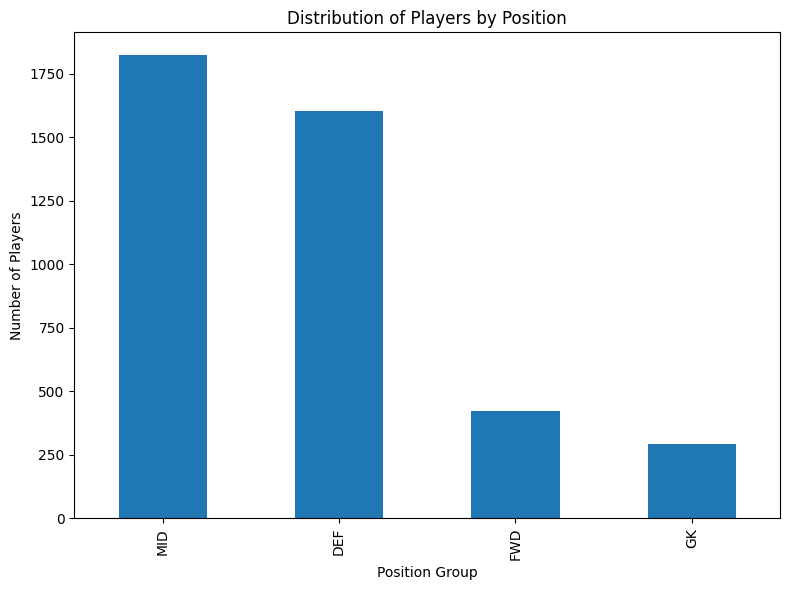

In [22]:
# Make of distrubution of players by position 
def map_position(pos):
    if pd.isna(pos):
        return "Unknown"
    pos = pos.upper()

    if "GK" in pos:
        return "GK"
    elif any(x in pos for x in ["DF", "DEF", "CB", "LB", "RB", "WB"]):
        return "DEF"
    elif any(x in pos for x in ["MF", "MID", "CM", "DM", "AM"]):
        return "MID"
    elif any(x in pos for x in ["FW", "FWD", "ST", "CF", "LW", "RW"]):
        return "FWD"
    else:
        return "OTHER"

model_df["position_group"] = model_df["Pos"].apply(map_position)

position_counts = model_df["position_group"].value_counts()

plt.figure(figsize=(8, 6))
position_counts.plot(kind="bar")

plt.title("Distribution of Players by Position")
plt.xlabel("Position Group")
plt.ylabel("Number of Players")

plt.tight_layout()
plt.show()

In [ ]:
# Modeling
gk_cols        = ["GA", "GA90", "SoTA", "Saves", "Save%", "CS", "CS%", "Save/90", "SoTA/90"]
attacking_cols = ["Sh", "SoT", "SoT%", "Sh/90", "SoT/90", "G/Sh", "G/SoT", "no_shots_flag"]
defense_cols   = ["2CrdY", "Fls", "Fld", "Off", "Crs", "Int", "TklW", "OG",
                  "DirectRCrd", "CrdY/90", "CrdR/90", "Fls/90"]

model_df[gk_cols]        = model_df[gk_cols].fillna(0)
model_df[attacking_cols] = model_df[attacking_cols].fillna(0)
model_df[defense_cols]   = model_df[defense_cols].fillna(0)

def simplify_pos(pos):
    if not isinstance(pos, str):
        return "Unknown"
    pos = pos.upper()
    if "GK" in pos:
        return "GK"
    elif "DF" in pos:
        return "DF"
    elif "MF" in pos:
        return "MF"
    elif "FW" in pos:
        return "FW"
    return "Unknown"

model_df["Pos_simple"] = model_df["Pos"].apply(simplify_pos)
pos_dummies = pd.get_dummies(model_df["Pos_simple"], prefix="pos", drop_first=True)
model_df    = pd.concat([model_df, pos_dummies], axis=1)

model_df["log_value"] = np.log1p(model_df["value"])

df_outfield = model_df[model_df["Pos_simple"] != "GK"].copy()
df_gk_model = model_df[model_df["Pos_simple"] == "GK"].copy()

print(f"Outfield rows : {len(df_outfield)}")
print(f"GK rows       : {len(df_gk_model)}")

OUTFIELD_FEATURES = [
    "Age", "MP", "Starts", "Min", "90s",
    "Gls", "Ast", "G+A", "G-PK", "PK", "PKatt",
    "CrdY", "CrdR", "G/90", "Ast/90", "G-PK/90",
    "G+A-PK/90", "G+A-PK", "SubIn",
    "Sh", "SoT", "SoT%", "Sh/90", "SoT/90", "G/Sh", "G/SoT",
    "2CrdY", "Fls", "Fld", "Off", "Crs", "Int", "TklW",
    "OG", "DirectRCrd", "CrdY/90", "CrdR/90", "Fls/90",
] + [c for c in pos_dummies.columns]
OUTFIELD_FEATURES = [f for f in OUTFIELD_FEATURES if f in df_outfield.columns]

GK_FEATURES = [
    "Age", "MP", "Starts", "Min", "90s",
    "CrdY", "CrdR",
    "GA", "GA90", "SoTA", "Saves", "Save%",
    "CS", "CS%", "Save/90", "SoTA/90",
    "Fls", "Int", "TklW", "CrdY/90", "Fls/90",
]
GK_FEATURES = [f for f in GK_FEATURES if f in df_gk_model.columns]

def run_model(df, features, label):
    X = df[features]
    y = df["log_value"]

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  Ridge(alpha=10.0))
    ])

    cv_r2  = cross_val_score(pipeline, X, y, cv=5, scoring="r2")
    cv_mae = cross_val_score(pipeline, X, y, cv=5, scoring="neg_mean_absolute_error")

    print(f"\n── {label} ──────────────────────────────")
    print(f"Rows          : {len(df)}")
    print(f"CV R²         : {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")
    print(f"CV MAE        : {(-cv_mae.mean()):.3f} ± {cv_mae.std():.3f}  (log scale)")

    pipeline.fit(X, y)

    coef_df = (
        pd.DataFrame({
            "feature":     features,
            "coefficient": pipeline.named_steps["model"].coef_
        })
        .assign(abs_coef=lambda d: d["coefficient"].abs())
        .sort_values("abs_coef", ascending=False)
        .reset_index(drop=True)
    )

    print(f"\nTop 15 drivers:")
    print(coef_df.head(15)[["feature", "coefficient"]].to_string(index=False))

    # Plot
    top    = coef_df.head(15).sort_values("coefficient")
    colors = ["#d73027" if c > 0 else "#4575b4" for c in top["coefficient"]]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top["feature"], top["coefficient"], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Coefficient (standardised)")
    ax.set_title(f"Top 15 Drivers of Market Value — {label}")
    plt.tight_layout()
    #plt.savefig(f"feature_importance_{label.lower().replace(' ', '_')}.png", dpi=150)
    plt.show()

    # Predictions
    df = df.copy()
    df["predicted_log_value"] = pipeline.predict(X)
    df["predicted_value"]     = np.expm1(df["predicted_log_value"])

    r2  = r2_score(y, df["predicted_log_value"])
    mae = mean_absolute_error(df["value"], df["predicted_value"])

    print(f"\nFull-data R²  : {r2:.3f}")
    print(f"Full-data MAE : €{mae:,.0f}")

    print("\nSample predictions vs actuals:")
    print(
        df[["player_name", "season", "value", "predicted_value"]]
        .sample(10, random_state=42)
        .assign(
            actual    = lambda d: d["value"].map("€{:,.0f}".format),
            predicted = lambda d: d["predicted_value"].map("€{:,.0f}".format)
        )[["player_name", "season", "actual", "predicted"]]
        .to_string(index=False)
    )

    return pipeline, coef_df, df

# Running the models
outfield_pipeline, outfield_coefs, df_outfield = run_model(
    df_outfield, OUTFIELD_FEATURES, "Outfield Players"
)
gk_pipeline, gk_coefs, df_gk_model = run_model(
    df_gk_model, GK_FEATURES, "Goalkeepers"
)

pd.concat([df_outfield, df_gk_model])
#pd.concat([df_outfield, df_gk_model]).to_csv("model_predictions.csv", index=False)
#outfield_coefs.to_csv("feature_importance_outfield.csv", index=False)
#gk_coefs.to_csv("feature_importance_gk.csv", index=False)
print(outfield_coefs)
print(gk_coefs)

In [ ]:
def engineer_features(df, is_gk=False):
    df = df.copy()

    if not is_gk:
        # Peak age indicator — value peaks 23-27
        df["is_peak_age"]  = df["Age"].between(23, 27).astype(int)
        df["is_young"]     = (df["Age"] < 23).astype(int)
        df["is_declining"] = (df["Age"] > 29).astype(int)

        # Goal involvement rate — single combined metric
        df["goal_involvement_90"] = (
            df["Gls"].fillna(0) + df["Ast"].fillna(0)
        ) / df["90s"].replace(0, np.nan)

        # Shot efficiency
        df["shot_efficiency"] = df["G/SoT"].fillna(0)

        # Defensive workload
        df["defensive_actions"] = (
            df["TklW"].fillna(0) + df["Int"].fillna(0) + df["Fls"].fillna(0)
        )

    else:
        df["is_peak_age"]  = df["Age"].between(25, 32).astype(int)
        df["is_young"]     = (df["Age"] < 25).astype(int)
        df["is_declining"] = (df["Age"] > 33).astype(int)

        # GK efficiency — saves per shot on target faced
        df["save_efficiency"] = df["Save%"].fillna(0)
        df["cs_rate"]         = df["CS%"].fillna(0)

    return df

df_outfield = engineer_features(df_outfield, is_gk=False)
df_gk_model = engineer_features(df_gk_model, is_gk=True)

# Add new features to feature lists
OUTFIELD_FEATURES_V2 = OUTFIELD_FEATURES + [
    "is_peak_age", "is_young", "is_declining",
    "goal_involvement_90", "shot_efficiency", "defensive_actions"
]
OUTFIELD_FEATURES_V2 = [f for f in OUTFIELD_FEATURES_V2 if f in df_outfield.columns]

GK_FEATURES_V2 = GK_FEATURES + [
    "is_peak_age", "is_young", "is_declining",
    "save_efficiency", "cs_rate"
]
GK_FEATURES_V2 = [f for f in GK_FEATURES_V2 if f in df_gk_model.columns]

def run_model(df, features, label):
    X = df[features].fillna(0)
    y = df["log_value"]

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  RandomForestRegressor(
            n_estimators=500,
            max_depth=6,          # reduced from 10 to reduce overfitting
            min_samples_leaf=10,  # increased to reduce overfitting
            max_features=0.6,     # use 60% of features per split
            n_jobs=-1,
            random_state=42
        ))
    ])

    cv_r2  = cross_val_score(pipeline, X, y, cv=5, scoring="r2")
    cv_mae = cross_val_score(pipeline, X, y, cv=5, scoring="neg_mean_absolute_error")

    print(f"\n── {label} | Random Forest v2 ──────────────────────────────")
    print(f"Rows   : {len(df)}")
    print(f"CV R²  : {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")
    print(f"CV MAE : {(-cv_mae.mean()):.3f} ± {cv_mae.std():.3f}  (log scale)")

    pipeline.fit(X, y)
    importances = pipeline.named_steps["model"].feature_importances_

    coef_df = (
        pd.DataFrame({"feature": features, "importance": importances})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    print(f"\nTop 15 drivers:")
    print(coef_df.head(15).to_string(index=False))

    # Plot
    top = coef_df.head(15).sort_values("importance")
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top["feature"], top["importance"], color="#d73027")
    ax.set_xlabel("Feature Importance")
    ax.set_title(f"Top 15 Drivers of Market Value — {label} (RF v2)")
    plt.tight_layout()
    #plt.savefig(f"feature_importance_{label.lower().replace(' ', '_')}_rf_v2.png", dpi=150)
    plt.show()

    # Predictions
    df = df.copy()
    df["predicted_log_value"] = pipeline.predict(X)
    df["predicted_value"]     = np.expm1(df["predicted_log_value"])

    r2  = r2_score(y, df["predicted_log_value"])
    mae = mean_absolute_error(df["value"], df["predicted_value"])

    print(f"\nFull-data R²  : {r2:.3f}")
    print(f"Full-data MAE : €{mae:,.0f}")

    print("\nSample predictions vs actuals:")
    print(
        df[["player_name", "season", "value", "predicted_value"]]
        .sample(10, random_state=42)
        .assign(
            actual    = lambda d: d["value"].map("€{:,.0f}".format),
            predicted = lambda d: d["predicted_value"].map("€{:,.0f}".format)
        )[["player_name", "season", "actual", "predicted"]]
        .to_string(index=False)
    )

    return pipeline, coef_df, df

# ── Run both models ───────────────────────────────────────────────────────────
outfield_pipeline, outfield_coefs, df_outfield = run_model(
    df_outfield, OUTFIELD_FEATURES_V2, "Outfield Players"
)
gk_pipeline, gk_coefs, df_gk_model = run_model(
    df_gk_model, GK_FEATURES_V2, "Goalkeepers"
)

pd.concat([df_outfield, df_gk_model])
#pd.concat([df_outfield, df_gk_model]).to_csv("model_predictions_v2.csv", index=False)
#outfield_coefs.to_csv("feature_importance_outfield_rf_v2.csv", index=False)
#gk_coefs.to_csv("feature_importance_gk_rf_v2.csv", index=False)
print(outfield_coefs)
print(gk_coefs)

In [ ]:
# Adding Club Tiers
club_tier = {
    # Tier 1 — Elite
    "Manchester City":      1, "Liverpool":            1,
    "Chelsea":              1, "Arsenal":              1,
    "Manchester Utd":       1, "Tottenham":            1,
    "Tottenham Hotspur":    1,
    "Real Madrid":          1, "Barcelona":            1,
    "Atlético Madrid":      1, "Atletico Madrid":      1,
    "Bayern Munich":        1, "Borussia Dortmund":    1,
    "Dortmund":             1,
    "RB Leipzig":           1,
    "Paris S-G":            1, "Paris Saint-Germain":  1,
    "Juventus":             1, "Inter":                1,
    "AC Milan":             1, "Milan":                1,
    "Napoli":               1,

    # Tier 2 — Strong
    "Sevilla":              2, "Valencia":             2,
    "Real Sociedad":        2, "Villarreal":           2,
    "Athletic Club":        2, "Real Betis":           2,
    "Celta Vigo":           2, "Osasuna":              2,
    "Alavés":               2,
    "Bayer Leverkusen":     2, "Leverkusen":           2,
    "Eintracht Frankfurt":  2, "Freiburg":             2,
    "Wolfsburg":            2, "Gladbach":             2,
    "Union Berlin":         2, "Hoffenheim":           2,
    "Werder Bremen":        2, "Augsburg":             2,
    "Mainz 05":             2, "Hertha BSC":           2,
    "Köln":                 2,
    "Lyon":                 2, "Marseille":            2,
    "Monaco":               2, "Lille":                2,
    "Rennes":               2, "Lens":                 2,
    "Nice":                 2, "Nantes":               2,
    "Montpellier":          2, "Saint-Étienne":        2,
    "Strasbourg":           2, "Angers":               2,
    "Metz":                 2,
    "Atalanta":             2, "Roma":                 2,
    "Lazio":                2, "Fiorentina":           2,
    "Torino":               2, "Bologna":              2,
    "Sassuolo":             2, "Udinese":              2,
    "Sampdoria":            2, "Genoa":                2,
    "Hellas Verona":        2, "Cagliari":             2,
    "West Ham":             2, "West Ham United":      2,
    "Leicester City":       2, "Everton":              2,
    "Newcastle Utd":        2, "Newcastle United":     2,
    "Aston Villa":          2, "Brighton":             2,
    "Wolves":               2, "Crystal Palace":       2,
    "Southampton":          2,
}

def get_club_tier(squad):
    if not isinstance(squad, str):
        return 3
    return club_tier.get(squad, 3)

model_df["club_tier"] = model_df["Squad"].apply(get_club_tier)

# Re-split after adding club_tier
df_outfield = model_df[model_df["Pos_simple"] != "GK"].copy()
df_gk_model = model_df[model_df["Pos_simple"] == "GK"].copy()

print("Club tier distribution:")
print(model_df["club_tier"].value_counts().sort_index())

print("\nStill in Tier 3 that look like they should be higher (top 20):")
print(
    model_df[model_df["club_tier"] == 3]["Squad"]
    .value_counts()
    .head(20)
)

OUTFIELD_FEATURES_V3 = OUTFIELD_FEATURES_V2 + ["club_tier"]
OUTFIELD_FEATURES_V3 = [f for f in OUTFIELD_FEATURES_V3 if f in df_outfield.columns]

GK_FEATURES_V3 = GK_FEATURES_V2 + ["club_tier"]
GK_FEATURES_V3 = [f for f in GK_FEATURES_V3 if f in df_gk_model.columns]

outfield_pipeline, outfield_coefs, df_outfield = run_model(
    df_outfield, OUTFIELD_FEATURES_V3, "Outfield Players"
)
gk_pipeline, gk_coefs, df_gk_model = run_model(
    df_gk_model, GK_FEATURES_V3, "Goalkeepers"
)

pd.concat([df_outfield, df_gk_model])
#pd.concat([df_outfield, df_gk_model]).to_csv("model_predictions_v3.csv", index=False)
#outfield_coefs.to_csv("feature_importance_outfield_rf_v3.csv", index=False)
#gk_coefs.to_csv("feature_importance_gk_rf_v3.csv", index=False)
print(outfield_coefs)
print(gk_coefs)

In [ ]:
#Best Random Forests
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def engineer_features(df, is_gk=False):
    df = df.copy()

    if not is_gk:
        df["is_peak_age"]  = df["Age"].between(23, 27).astype(int)
        df["is_young"]     = (df["Age"] < 23).astype(int)
        df["is_declining"] = (df["Age"] > 29).astype(int)

        df["goal_involvement_90"] = (
            df["Gls"].fillna(0) + df["Ast"].fillna(0)
        ) / df["90s"].replace(0, np.nan)

        df["shot_efficiency"]     = df["G/SoT"].fillna(0)

        df["defensive_actions"]   = (
            df["TklW"].fillna(0) + df["Int"].fillna(0) + df["Fls"].fillna(0)
        )

        df["min_per_game"]        = (
            df["Min"].fillna(0) / df["MP"].replace(0, np.nan)
        )

        df["goal_contrib_per_sh"] = (
            df["G+A-PK"].fillna(0) / df["Sh"].replace(0, np.nan)
        )

    else:
        df["is_peak_age"]  = df["Age"].between(25, 32).astype(int)
        df["is_young"]     = (df["Age"] < 25).astype(int)
        df["is_declining"] = (df["Age"] > 33).astype(int)

        df["save_efficiency"] = df["Save%"].fillna(0)
        df["cs_rate"]         = df["CS%"].fillna(0)

        df["cs_per_90"]    = (
            df["CS"].fillna(0) / df["90s"].replace(0, np.nan)
        )

        df["ga_per_sota"]  = (
            df["GA"].fillna(0) / df["SoTA"].replace(0, np.nan)
        )

    return df

df_outfield = engineer_features(df_outfield, is_gk=False)
df_gk_model = engineer_features(df_gk_model, is_gk=True)

OUTFIELD_FEATURES_FINAL = [
    # Context
    "club_tier",
    # Age
    "Age", "is_peak_age", "is_young", "is_declining",
    # Playing time
    "MP", "Starts", "Min", "SubIn", "min_per_game",# "90s"
    # Goal output
    "Gls", "Ast", "G+A", "G-PK", "PK", "PKatt",
    "G+A-PK", "G+A-PK/90", "G-PK/90",
    # Rates
    "G/90", "Ast/90", "goal_involvement_90",
    # Shooting
    "Sh", "SoT", "SoT%", "Sh/90", "SoT/90",
    "G/Sh", "G/SoT", "shot_efficiency", "goal_contrib_per_sh",
    # Defense
    "Fls", "Fld", "Off", "Crs", "Int", "TklW",
    "2CrdY", "OG", "DirectRCrd",
    "CrdY/90", "CrdR/90", "Fls/90", "defensive_actions",
    # Discipline
    "CrdY", "CrdR",
    # Position dummies
] + [c for c in pos_dummies.columns]
OUTFIELD_FEATURES_FINAL = [
    f for f in OUTFIELD_FEATURES_FINAL if f in df_outfield.columns
]

GK_FEATURES_FINAL = [
    # Context
    "club_tier",
    # Age
    "Age", "is_peak_age", "is_young", "is_declining",
    # Playing time
    "MP", "Starts", "Min",# "90s",
    # GK core
    "GA", "GA90", "SoTA", "Saves", "Save%",
    "CS", "CS%", "Save/90", "SoTA/90",
    # Engineered
    "save_efficiency", "cs_rate", "cs_per_90", "ga_per_sota",
    # Discipline
    "CrdY", "CrdR", "CrdY/90", "Fls/90",
    "Fls", "Int", "TklW",
]
GK_FEATURES_FINAL = [
    f for f in GK_FEATURES_FINAL if f in df_gk_model.columns
]

def run_final_rf_model(df, features, label):
    X = df[features].fillna(0)
    y = df["log_value"]

    # 80/20 train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  RandomForestRegressor(
            n_estimators=700,
            max_depth=12,
            min_samples_leaf=5,
            max_features=0.6,
            n_jobs=-1,
            random_state=42
        ))
    ])

    cv_r2  = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="r2")
    cv_mae = cross_val_score(pipeline, X_train, y_train, cv=5,
                             scoring="neg_mean_absolute_error")

    pipeline.fit(X_train, y_train)

    test_preds = pipeline.predict(X_test)
    test_r2    = r2_score(y_test, test_preds)
    test_mae   = mean_absolute_error(
        np.expm1(y_test), np.expm1(test_preds)
    )
    # MSE
    test_mse = mean_squared_error(
    np.expm1(y_test),
    np.expm1(test_preds)
    )

    # RMSE
    test_rmse = np.sqrt(test_mse)

    print(f"\n── {label} | Final Random Forest ──────────────────────────────")
    print(f"Train rows    : {len(X_train)}")
    print(f"Test rows     : {len(X_test)}")
    print(f"CV R²         : {cv_r2.mean():.3f} ± {cv_r2.std():.3f}  (train set)")
    print(f"CV MAE        : {(-cv_mae.mean()):.3f} ± {cv_mae.std():.3f}  (log scale)")
    print(f"Test R²       : {test_r2:.3f}  ← honest performance on unseen data")
    print(f"Test MAE      : €{test_mae:,.0f}")
    print(f"Test MSE   : {test_mse:,.0f}")
    print(f"Test RMSE  : €{test_rmse:,.0f}")

    # Feature importance
    importances = pipeline.named_steps["model"].feature_importances_
    coef_df = (
        pd.DataFrame({"feature": features, "importance": importances})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    print(f"\nTop 15 drivers:")
    print(coef_df.head(15).to_string(index=False))

    # Plot
    top    = coef_df.head(15).sort_values("importance")
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top["feature"], top["importance"], color="#d73027")
    ax.set_xlabel("Feature Importance")
    ax.set_title(f"Top 15 Drivers of Market Value — {label} (Final RF)")
    plt.tight_layout()
    #plt.savefig(f"feature_importance_{label.lower().replace(' ', '_')}_final.png",dpi=150)
    plt.show()

    df = df.copy()
    df["predicted_log_value"] = pipeline.predict(X)
    df["predicted_value"]     = np.expm1(df["predicted_log_value"])
    df["in_test_set"]         = False
    df.loc[X_test.index, "in_test_set"] = True

    # Evaluate on test set rows only
    test_df = df[df["in_test_set"]].copy()
    test_df["abs_error"] = (test_df["value"] - test_df["predicted_value"]).abs()

    print(f"\nWorst 10 predictions on TEST SET:")
    print(
        test_df.nlargest(10, "abs_error")
        .assign(
            actual    = lambda d: d["value"].map("€{:,.0f}".format),
            predicted = lambda d: d["predicted_value"].map("€{:,.0f}".format),
            error     = lambda d: d["abs_error"].map("€{:,.0f}".format)
        )[["player_name", "season", "actual", "predicted", "error"]]
        .to_string(index=False)
    )

    print(f"\nSample predictions from TEST SET:")
    print(
        test_df[["player_name", "season", "value", "predicted_value"]]
        .sample(10, random_state=42)
        .assign(
            actual    = lambda d: d["value"].map("€{:,.0f}".format),
            predicted = lambda d: d["predicted_value"].map("€{:,.0f}".format)
        )[["player_name", "season", "actual", "predicted"]]
        .to_string(index=False)
    )

    return pipeline, coef_df, df

# ── 5. RUN BOTH MODELS ────────────────────────────────────────────────────────
outfield_rf_pipeline, outfield_rf_coefs, df_outfield = run_final_rf_model(
    df_outfield, OUTFIELD_FEATURES_FINAL, "Outfield Players"
)
gk_rf_pipeline, gk_rf_coefs, df_gk_model = run_final_rf_model(
    df_gk_model, GK_FEATURES_FINAL, "Goalkeepers"
)

# ── 6. SAVE EVERYTHING ───────────────────────────────────────────────────────
pd.concat([df_outfield, df_gk_model])
#pd.concat([df_outfield, df_gk_model]).to_csv("model_predictions_rf_final.csv", index=False)
#outfield_rf_coefs.to_csv("feature_importance_outfield_rf_final.csv", index=False)
#gk_rf_coefs.to_csv("feature_importance_gk_rf_final.csv",             index=False)

print(outfield_rf_coefs)
print(gk_rf_coefs)

In [ ]:
# Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error

def engineer_features(df, is_gk=False):
    df = df.copy()

    if not is_gk:
        df["is_peak_age"]  = df["Age"].between(23, 27).astype(int)
        df["is_young"]     = (df["Age"] < 23).astype(int)
        df["is_declining"] = (df["Age"] > 29).astype(int)

        df["goal_involvement_90"] = (
            df["Gls"].fillna(0) + df["Ast"].fillna(0)
        ) / df["90s"].replace(0, np.nan)

        df["shot_efficiency"]     = df["G/SoT"].fillna(0)

        df["defensive_actions"]   = (
            df["TklW"].fillna(0) + df["Int"].fillna(0) + df["Fls"].fillna(0)
        )

        df["min_per_game"]        = (
            df["Min"].fillna(0) / df["MP"].replace(0, np.nan)
        )

        df["goal_contrib_per_sh"] = (
            df["G+A-PK"].fillna(0) / df["Sh"].replace(0, np.nan)
        )

    else:
        df["is_peak_age"]  = df["Age"].between(25, 32).astype(int)
        df["is_young"]     = (df["Age"] < 25).astype(int)
        df["is_declining"] = (df["Age"] > 33).astype(int)

        df["save_efficiency"] = df["Save%"].fillna(0)
        df["cs_rate"]         = df["CS%"].fillna(0)

        df["cs_per_90"]    = (
            df["CS"].fillna(0) / df["90s"].replace(0, np.nan)
        )

        df["ga_per_sota"]  = (
            df["GA"].fillna(0) / df["SoTA"].replace(0, np.nan)
        )

    return df

df_outfield = engineer_features(df_outfield, is_gk=False)
df_gk_model = engineer_features(df_gk_model, is_gk=True)

OUTFIELD_FEATURES_FINAL = [
    "club_tier",
    "Age", "is_peak_age", "is_young", "is_declining",
    "MP", "Starts", "Min", "SubIn", "min_per_game",
    "Gls", "Ast", "G+A", "G-PK", "PK", "PKatt",
    "G+A-PK", "G+A-PK/90", "G-PK/90",
    "G/90", "Ast/90", "goal_involvement_90",
    "Sh", "SoT", "SoT%", "Sh/90", "SoT/90",
    "G/Sh", "G/SoT", "shot_efficiency", "goal_contrib_per_sh",
    "Fls", "Fld", "Off", "Crs", "Int", "TklW",
    "2CrdY", "OG", "DirectRCrd",
    "CrdY/90", "CrdR/90", "Fls/90", "defensive_actions",
    "CrdY", "CrdR", #"90s",
] + [c for c in pos_dummies.columns]
OUTFIELD_FEATURES_FINAL = [
    f for f in OUTFIELD_FEATURES_FINAL if f in df_outfield.columns
]

GK_FEATURES_FINAL = [
    "club_tier",
    "Age", "is_peak_age", "is_young", "is_declining",
    "MP", "Starts", "Min",
    "GA", "GA90", "SoTA", "Saves", "Save%",
    "CS", "CS%", "Save/90", "SoTA/90",
    "save_efficiency", "cs_rate", "cs_per_90", "ga_per_sota",
    "CrdY", "CrdR", "CrdY/90", "Fls/90",
    "Fls", "Int", "TklW",#, "90s",
]
GK_FEATURES_FINAL = [
    f for f in GK_FEATURES_FINAL if f in df_gk_model.columns
]

def run_final_lr_model(df, features, label):
    X = df[features].fillna(0)
    y = df["log_value"]

    # 80/20 train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  LinearRegression())  # No hyperparameters needed
    ])

    # CV on training set only
    cv_r2  = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="r2")
    cv_mae = cross_val_score(pipeline, X_train, y_train, cv=5,
                             scoring="neg_mean_absolute_error")

    # Fit on full training set
    pipeline.fit(X_train, y_train)

    # Evaluate on holdout test set
    test_preds = pipeline.predict(X_test)
    test_r2    = r2_score(y_test, test_preds)
    test_mae   = mean_absolute_error(
        np.expm1(y_test), np.expm1(test_preds)
    )
    # MSE
    test_mse = mean_squared_error(
    np.expm1(y_test),
    np.expm1(test_preds)
    )

    # RMSE
    test_rmse = np.sqrt(test_mse)

    print(f"\n── {label} | Linear Regression ──────────────────────────────")
    print(f"Train rows    : {len(X_train)}")
    print(f"Test rows     : {len(X_test)}")
    print(f"CV R²         : {cv_r2.mean():.3f} ± {cv_r2.std():.3f}  (train set)")
    print(f"CV MAE        : {(-cv_mae.mean()):.3f} ± {cv_mae.std():.3f}  (log scale)")
    print(f"Test R²       : {test_r2:.3f}  ← honest performance on unseen data")
    print(f"Test MAE      : €{test_mae:,.0f}")
    print(f"Test MSE   : {test_mse:,.0f}")
    print(f"Test RMSE  : €{test_rmse:,.0f}")

    # Coefficients instead of feature importances
    coefficients = pipeline.named_steps["model"].coef_
    coef_df = (
        pd.DataFrame({"feature": features, "coefficient": coefficients})
        .assign(abs_coefficient=lambda d: d["coefficient"].abs())
        .sort_values("abs_coefficient", ascending=False)
        .reset_index(drop=True)
    )

    print(f"\nTop 15 drivers (by absolute coefficient):")
    print(coef_df[["feature", "coefficient"]].head(15).to_string(index=False))

    # Plot
    top = coef_df.head(15).sort_values("abs_coefficient")
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ["#d73027" if c > 0 else "#4575b4" for c in top["coefficient"]]
    ax.barh(top["feature"], top["coefficient"], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Coefficient (log scale)")
    ax.set_title(f"Top 15 Drivers of Market Value — {label} (Linear Regression)")
    plt.tight_layout()
    #plt.savefig(f"feature_importance_{label.lower().replace(' ', '_')}_lr.png",dpi=150)
    plt.show()

    df = df.copy()
    df["predicted_log_value"] = pipeline.predict(X)
    df["predicted_value"]     = np.expm1(df["predicted_log_value"])
    df["in_test_set"]         = False
    df.loc[X_test.index, "in_test_set"] = True

    test_df = df[df["in_test_set"]].copy()
    test_df["abs_error"] = (test_df["value"] - test_df["predicted_value"]).abs()

    print(f"\nWorst 10 predictions on TEST SET:")
    print(
        test_df.nlargest(10, "abs_error")
        .assign(
            actual    = lambda d: d["value"].map("€{:,.0f}".format),
            predicted = lambda d: d["predicted_value"].map("€{:,.0f}".format),
            error     = lambda d: d["abs_error"].map("€{:,.0f}".format)
        )[["player_name", "season", "actual", "predicted", "error"]]
        .to_string(index=False)
    )

    print(f"\nSample predictions from TEST SET:")
    print(
        test_df[["player_name", "season", "value", "predicted_value"]]
        .sample(10, random_state=42)
        .assign(
            actual    = lambda d: d["value"].map("€{:,.0f}".format),
            predicted = lambda d: d["predicted_value"].map("€{:,.0f}".format)
        )[["player_name", "season", "actual", "predicted"]]
        .to_string(index=False)
    )

    return pipeline, coef_df, df

outfield_lr_pipeline, outfield_lr_coefs, df_outfield = run_final_lr_model(
    df_outfield, OUTFIELD_FEATURES_FINAL, "Outfield Players"
)
gk_pipeline, gk_lr_coefs, df_gk_model = run_final_lr_model(
    df_gk_model, GK_FEATURES_FINAL, "Goalkeepers"
)

pd.concat([df_outfield, df_gk_model])
#pd.concat([df_outfield, df_gk_model]).to_csv("model_predictions_lr.csv", index=False)
#outfield_lr_coefs.to_csv("feature_importance_outfield_lr.csv", index=False)
#gk_lr_coefs.to_csv("feature_importance_gk_lr.csv", index=False)

print(outfield_lr_coefs)
print(gk_lr_coefs)

-------------------------------------------------------------------------------------------
-------------------------- Doing Individual Leagues --------------------------
-------------------------------------------------------------------------------------------

In [ ]:
#EPL Linear Regression
epl_teams = [
    "Arsenal", "Aston Villa", "Bournemouth", "Brentford",
    "Brighton", "Burnley", "Chelsea", "Crystal Palace",
    "Everton", "Fulham", "Huddersfield Town", "Hull City",
    "Ipswich Town", "Leeds United", "Leicester City",
    "Liverpool", "Luton Town", "Manchester City",
    "Manchester Utd", "Newcastle United",
    "Norwich City", "Nottingham Forest",
    "Sheffield United", "Southampton", "Stoke City",
    "Sunderland", "Swansea City", "Tottenham Hotspur",
    "Watford", "West Brom", "West Ham United", "Wolves"
]

df_epl_outfield = df_outfield[
    df_outfield["Squad"].isin(epl_teams)
].copy()

df_epl_gk = df_gk_model[
    df_gk_model["Squad"].isin(epl_teams)
].copy()

print("EPL Outfield Rows:", len(df_epl_outfield))
print("EPL GK Rows:", len(df_epl_gk))


df_epl_outfield = engineer_features(df_epl_outfield, is_gk=False)
df_epl_gk       = engineer_features(df_epl_gk, is_gk=True)


EPL_OUTFIELD_FEATURES = [
    f for f in OUTFIELD_FEATURES_FINAL
    if f in df_epl_outfield.columns
]

EPL_GK_FEATURES = [
    f for f in GK_FEATURES_FINAL
    if f in df_epl_gk.columns
]


epl_lr_outfield_pipeline, epl_lr_outfield_coefs, df_epl_outfield = run_final_lr_model(
    df_epl_outfield,
    EPL_OUTFIELD_FEATURES,
    "EPL Outfield Players"
)

epl_lr_gk_pipeline, epl_lr_gk_coefs, df_epl_gk = run_final_lr_model(
    df_epl_gk,
    EPL_GK_FEATURES,
    "EPL Goalkeepers"
)

pd.concat([df_epl_outfield, df_epl_gk])
#pd.concat([df_epl_outfield, df_epl_gk]).to_csv("epl_model_predictions_final.csv",index=False)

#epl_lr_outfield_coefs.to_csv("feature_importance_epl_outfield_final.csv",index=False)
#epl_lr_gk_coefs.to_csv("feature_importance_epl_gk_final.csv",index=False)

print(epl_lr_outfield_coefs)
print(epl_lr_gk_coefs)

In [ ]:
#La Liga Linear Regression
la_liga_teams = [
    "Alavés", "Almería", "Athletic Club", "Atlético Madrid",
    "Barcelona", "Celta Vigo", "Cádiz", "Dep La Coruña",
    "Eibar", "Elche", "Espanyol", "Getafe",
    "Girona", "Granada", "Huesca", "Las Palmas",
    "Leganés", "Levante", "Mallorca", "Málaga",
    "Osasuna", "Rayo Vallecano", "Real Betis",
    "Real Madrid", "Real Sociedad", "Sevilla",
    "Sporting Gijón", "Valencia", "Valladolid",
    "Villarreal"
]

df_la_liga_outfield = df_outfield[
    df_outfield["Squad"].isin(la_liga_teams)
].copy()

df_la_liga_gk = df_gk_model[
    df_gk_model["Squad"].isin(la_liga_teams)
].copy()

print("La Liga Outfield Rows:", len(df_la_liga_outfield))
print("La Liga GK Rows:", len(df_la_liga_gk))


df_la_liga_outfield = engineer_features(df_la_liga_outfield, is_gk=False)
df_la_liga_gk       = engineer_features(df_la_liga_gk, is_gk=True)


LA_LIGA_OUTFIELD_FEATURES = [
    f for f in OUTFIELD_FEATURES_FINAL
    if f in df_la_liga_outfield.columns
]

LA_LIGA_GK_FEATURES = [
    f for f in GK_FEATURES_FINAL
    if f in df_la_liga_gk.columns
]


la_liga_lr_outfield_pipeline, la_liga_lr_outfield_coefs, df_la_liga_outfield = run_final_lr_model(
    df_la_liga_outfield,
    LA_LIGA_OUTFIELD_FEATURES,
    "La Liga Outfield Players"
)

la_liga_lr_gk_pipeline, la_liga_lr_gk_coefs, df_la_liga_gk = run_final_lr_model(
    df_la_liga_gk,
    LA_LIGA_GK_FEATURES,
    "La Liga Goalkeepers"
)

pd.concat([df_la_liga_outfield, df_la_liga_gk])
#pd.concat([df_la_liga_outfield, df_la_liga_gk]).to_csv(
    #"la_liga_model_predictions_final.csv",
    #index=False
#)

#la_liga_lr_outfield_coefs.to_csv(
    #"feature_importance_la_liga_outfield_final.csv",
    #index=False
#)

#la_liga_lr_gk_coefs.to_csv(
    #"feature_importance_la_liga_gk_final.csv",
    #index=False
#)

print("\nLa_Liga models complete and saved.")

In [ ]:
#Bundesliga Linear Regression
bundesliga_teams = [
    "Arminia", "Augsburg", "Bayern Munich", "Bochum",
    "Darmstadt 98", "Dortmund", "Düsseldorf",
    "Eintracht Frankfurt", "Freiburg", "Gladbach",
    "Greuther Fürth", "Hamburger SV", "Hannover 96",
    "Heidenheim", "Hertha BSC", "Hoffenheim",
    "Holstein Kiel", "Ingolstadt", "Köln",
    "Leverkusen", "Mainz 05", "Paderborn 07",
    "RB Leipzig", "Schalke 04", "St Pauli",
    "Stuttgart", "Union Berlin", "Werder Bremen",
    "Wolfsburg"
]

df_bundesliga_outfield = df_outfield[
    df_outfield["Squad"].isin(bundesliga_teams)
].copy()

df_bundesliga_gk = df_gk_model[
    df_gk_model["Squad"].isin(bundesliga_teams)
].copy()

print("Bundesliga Outfield Rows:", len(df_bundesliga_outfield))
print("Bundesliga GK Rows:", len(df_bundesliga_gk))


df_bundesliga_outfield = engineer_features(df_bundesliga_outfield, is_gk=False)
df_bundesliga_gk       = engineer_features(df_bundesliga_gk, is_gk=True)


BUNDESLIGA_OUTFIELD_FEATURES = [
    f for f in OUTFIELD_FEATURES_FINAL
    if f in df_bundesliga_outfield.columns
]

BUNDESLIGA_GK_FEATURES = [
    f for f in GK_FEATURES_FINAL
    if f in df_bundesliga_gk.columns
]


bundesliga_lr_outfield_pipeline, bundesliga_lr_outfield_coefs, df_bundesliga_outfield = run_final_lr_model(
    df_bundesliga_outfield,
    BUNDESLIGA_OUTFIELD_FEATURES,
    "Bundesliga Outfield Players"
)

bundesliga_lr_gk_pipeline, bundesliga_lr_gk_coefs, df_bundesliga_gk = run_final_lr_model(
    df_bundesliga_gk,
    BUNDESLIGA_GK_FEATURES,
    "Bundesliga Goalkeepers"
)

pd.concat([df_bundesliga_outfield, df_bundesliga_gk])
#pd.concat([df_bundesliga_outfield, df_bundesliga_gk]).to_csv(
    #"bundesliga_model_predictions_final.csv",
    #index=False
#)

#bundesliga_lr_outfield_coefs.to_csv(
   # "feature_importance_bundesliga_outfield_final.csv",
    #index=False
#)

#bundesliga_lr_gk_coefs.to_csv(
    #"feature_importance_bundesliga_gk_final.csv",
   # index=False
#)

print("\nBundesliga models complete and saved.")

In [ ]:
#Serie A Linear Regression
serie_a_teams = [
    "Atalanta", "Benevento", "Bologna", "Brescia",
    "Cagliari", "Chievo", "Como", "Cremonese",
    "Crotone", "Empoli", "Fiorentina", "Frosinone",
    "Genoa", "Hellas Verona", "Inter",
    "Juventus", "Lazio", "Lecce", "Milan",
    "Monza", "Napoli", "Palermo", "Parma",
    "Pescara", "Roma", "SPAL", "Salernitana",
    "Sampdoria", "Sassuolo", "Spezia",
    "Torino", "Udinese", "Venezia"
]

df_serie_a_outfield = df_outfield[
    df_outfield["Squad"].isin(serie_a_teams)
].copy()

df_serie_a_gk = df_gk_model[
    df_gk_model["Squad"].isin(serie_a_teams)
].copy()

print("Serie A Outfield Rows:", len(df_serie_a_outfield))
print("Serie A GK Rows:", len(df_serie_a_gk))


df_serie_a_outfield = engineer_features(df_serie_a_outfield, is_gk=False)
df_serie_a_gk       = engineer_features(df_serie_a_gk, is_gk=True)


SERIA_A_OUTFIELD_FEATURES = [
    f for f in OUTFIELD_FEATURES_FINAL
    if f in df_serie_a_outfield.columns
]

SERIA_A_GK_FEATURES = [
    f for f in GK_FEATURES_FINAL
    if f in df_serie_a_gk.columns
]


serie_a_lr_outfield_pipeline, serie_a_lr_outfield_coefs, df_serie_a_outfield = run_final_lr_model(
    df_serie_a_outfield,
    SERIA_A_OUTFIELD_FEATURES,
    "Serie A Outfield Players"
)

serie_a_lr_gk_pipeline, serie_a_lr_gk_coefs, df_serie_a_gk = run_final_lr_model(
    df_serie_a_gk,
    SERIA_A_GK_FEATURES,
    "Serie A Goalkeepers"
)

pd.concat([df_serie_a_outfield, df_serie_a_gk])
#pd.concat([df_serie_a_outfield, df_serie_a_gk]).to_csv(
    #"serie_a_model_predictions_final.csv",
    #index=False
#)

#serie_a_lr_outfield_coefs.to_csv(
    #"feature_importance_serie_a_outfield_final.csv",
    #index=False
#)

#serie_a_lr_gk_coefs.to_csv(
    #"feature_importance_serie_a_gk_final.csv",
    #index=False
#)

print("\nSerie A models complete and saved.")

In [ ]:
#Ligue 1 Linear Regression
ligue1_teams = [
    "Ajaccio", "Amiens", "Angers", "Auxerre",
    "Bastia", "Bordeaux", "Brest", "Caen",
    "Clermont Foot", "Dijon", "Guingamp",
    "Le Havre", "Lens", "Lille", "Lorient",
    "Lyon", "Marseille", "Metz", "Monaco",
    "Montpellier", "Nancy", "Nantes", "Nice",
    "Nîmes", "Paris Saint-Germain", "Reims",
    "Rennes", "Saint-Étienne", "Strasbourg",
    "Toulouse", "Troyes"
]

df_ligue1_outfield = df_outfield[
    df_outfield["Squad"].isin(ligue1_teams)
].copy()

df_ligue1_gk = df_gk_model[
    df_gk_model["Squad"].isin(ligue1_teams)
].copy()

print("Ligue 1 Outfield Rows:", len(df_ligue1_outfield))
print("Ligue 1 GK Rows:", len(df_ligue1_gk))


df_ligue1_outfield = engineer_features(df_ligue1_outfield, is_gk=False)
df_ligue1_gk       = engineer_features(df_ligue1_gk, is_gk=True)


LIGUE1_OUTFIELD_FEATURES = [
    f for f in OUTFIELD_FEATURES_FINAL
    if f in df_ligue1_outfield.columns
]

LIGUE1_GK_FEATURES = [
    f for f in GK_FEATURES_FINAL
    if f in df_ligue1_gk.columns
]


ligue1_lr_outfield_pipeline, ligue1_lr_outfield_coefs, df_ligue1_outfield = run_final_lr_model(
    df_ligue1_outfield,
    LIGUE1_OUTFIELD_FEATURES,
    "Ligue 1 Outfield Players"
)

ligue1_lr_gk_pipeline, ligue1_lr_gk_coefs, df_ligue1_gk = run_final_lr_model(
    df_ligue1_gk,
    LIGUE1_GK_FEATURES,
    "Ligue 1 Goalkeepers"
)

pd.concat([df_ligue1_outfield, df_ligue1_gk])
#pd.concat([df_ligue1_outfield, df_ligue1_gk]).to_csv(
    #"ligue1_model_predictions_final.csv",
    #index=False
#)

#ligue1_lr_outfield_coefs.to_csv(
    #"feature_importance_ligue1_outfield_final.csv",
    #index=False
#)

#ligue1_lr_gk_coefs.to_csv(
    #"feature_importance_ligue1_gk_final.csv",
    #index=False
#)

print("\nLigue 1 models complete and saved.")

In [ ]:
#EPL Random Forests
df_epl_outfield = df_outfield[
    df_outfield["Squad"].isin(epl_teams)
].copy()

df_epl_gk = df_gk_model[
    df_gk_model["Squad"].isin(epl_teams)
].copy()

print("EPL Outfield Rows:", len(df_epl_outfield))
print("EPL GK Rows:", len(df_epl_gk))



df_epl_outfield = engineer_features(df_epl_outfield, is_gk=False)
df_epl_gk       = engineer_features(df_epl_gk, is_gk=True)


EPL_OUTFIELD_FEATURES = [
    # Context
    "club_tier",

    # Age
    "Age", "is_peak_age", "is_young", "is_declining",

    # Playing time
    "MP", "Starts", "Min", "SubIn", "min_per_game", 

    # Goal output
    "Gls", "Ast", "G+A", "G-PK", "PK", "PKatt",
    "G+A-PK", "G+A-PK/90", "G-PK/90",

    # Rates
    "G/90", "Ast/90", "goal_involvement_90",

    # Shooting
    "Sh", "SoT", "SoT%", "Sh/90", "SoT/90",
    "G/Sh", "G/SoT", "shot_efficiency", "goal_contrib_per_sh",

    # Defense
    "Fls", "Fld", "Off", "Crs", "Int", "TklW",
    "2CrdY", "OG", "DirectRCrd",
    "CrdY/90", "CrdR/90", "Fls/90", "defensive_actions",

    # Discipline
    "CrdY", "CrdR",

] + [c for c in pos_dummies.columns]

EPL_OUTFIELD_FEATURES = [
    f for f in EPL_OUTFIELD_FEATURES
    if f in df_epl_outfield.columns
]


EPL_GK_FEATURES = [
    # Context
    "club_tier",

    # Age
    "Age", "is_peak_age", "is_young", "is_declining",

    # Playing time
    "MP", "Starts", "Min", 

    # GK core
    "GA", "GA90", "SoTA", "Saves", "Save%",
    "CS", "CS%", "Save/90", "SoTA/90",

    # Engineered
    "save_efficiency", "cs_rate",
    "cs_per_90", "ga_per_sota",

    # Discipline
    "CrdY", "CrdR", "CrdY/90",
    "Fls/90", "Fls", "Int", "TklW",
]

EPL_GK_FEATURES = [
    f for f in EPL_GK_FEATURES
    if f in df_epl_gk.columns
]


epl_rf_outfield_pipeline, epl_rf_outfield_coefs, df_epl_outfield = run_final_rf_model(
    df_epl_outfield,
    EPL_OUTFIELD_FEATURES,
    "EPL Outfield Players"
)

epl_rf_gk_pipeline, epl_rf_gk_coefs, df_epl_gk = run_final_rf_model(
    df_epl_gk,
    EPL_GK_FEATURES,
    "EPL Goalkeepers"
)
pd.concat([df_epl_outfield, df_epl_gk])
#pd.concat([df_epl_outfield, df_epl_gk]).to_csv(
    #"epl_model_predictions_final.csv",
    #index=False
#)

#epl_rf_outfield_coefs.to_csv(
   # "feature_importance_epl_outfield_final.csv",
   # index=False
#)

#epl_rf_gk_coefs.to_csv(
#    "feature_importance_epl_gk_final.csv",
#    index=False
#)

print("\nEPL Random Forest models complete and saved.")

In [ ]:
#Bundesliga Random Forests
df_bundesliga_outfield = df_outfield[
    df_outfield["Squad"].isin(bundesliga_teams)
].copy()

df_bundesliga_gk = df_gk_model[
    df_gk_model["Squad"].isin(bundesliga_teams)
].copy()

print("Bundesliga Outfield Rows:", len(df_bundesliga_outfield))
print("Bundesliga GK Rows:", len(df_bundesliga_gk))


# ── 1. APPLY FEATURE ENGINEERING ──────────────────────────────────────────────
df_bundesliga_outfield = engineer_features(df_bundesliga_outfield, is_gk=False)
df_bundesliga_gk       = engineer_features(df_bundesliga_gk, is_gk=True)


# ── 2. Bundesliga FEATURE LISTS ──────────────────────────────────────────────────────
BUNDESLIGA_OUTFIELD_FEATURES = [
    # Context
    "club_tier",

    # Age
    "Age", "is_peak_age", "is_young", "is_declining",

    # Playing time
    "MP", "Starts", "Min", "SubIn", "min_per_game",

    # Goal output
    "Gls", "Ast", "G+A", "G-PK", "PK", "PKatt",
    "G+A-PK", "G+A-PK/90", "G-PK/90",

    # Rates
    "G/90", "Ast/90", "goal_involvement_90",

    # Shooting
    "Sh", "SoT", "SoT%", "Sh/90", "SoT/90",
    "G/Sh", "G/SoT", "shot_efficiency", "goal_contrib_per_sh",

    # Defense
    "Fls", "Fld", "Off", "Crs", "Int", "TklW",
    "2CrdY", "OG", "DirectRCrd",
    "CrdY/90", "CrdR/90", "Fls/90", "defensive_actions",

    # Discipline
    "CrdY", "CrdR",

] + [c for c in pos_dummies.columns]

BUNDESLIGA_OUTFIELD_FEATURES = [
    f for f in BUNDESLIGA_OUTFIELD_FEATURES
    if f in df_bundesliga_outfield.columns
]


BUNDESLIGA_GK_FEATURES = [
    # Context
    "club_tier",

    # Age
    "Age", "is_peak_age", "is_young", "is_declining",

    # Playing time
    "MP", "Starts", "Min",

    # GK core
    "GA", "GA90", "SoTA", "Saves", "Save%",
    "CS", "CS%", "Save/90", "SoTA/90",

    # Engineered
    "save_efficiency", "cs_rate",
    "cs_per_90", "ga_per_sota",

    # Discipline
    "CrdY", "CrdR", "CrdY/90",
    "Fls/90", "Fls", "Int", "TklW",
]

BUNDESLIGA_GK_FEATURES = [
    f for f in BUNDESLIGA_GK_FEATURES
    if f in df_bundesliga_gk.columns
]


bundesliga_rf_outfield_pipeline, bundesliga_rf_outfield_coefs, df_bundesliga_outfield = run_final_rf_model(
    df_bundesliga_outfield,
    BUNDESLIGA_OUTFIELD_FEATURES,
    "Bundesliga Outfield Players"
)

bundesliga_rf_gk_pipeline, bundesliga_rf_gk_coefs, df_bundesliga_gk = run_final_rf_model(
    df_bundesliga_gk,
    BUNDESLIGA_GK_FEATURES,
    "Bundesliga Goalkeepers"
)

pd.concat([df_bundesliga_outfield, df_bundesliga_gk])
#pd.concat([df_bundesliga_outfield, df_bundesliga_gk]).to_csv(
#    "bundesliga_model_predictions_final.csv",
#    index=False
#)

#bundesliga_rf_outfield_coefs.to_csv(
#    "feature_importance_bundesliga_outfield_final.csv",
#    index=False
#)

#bundesliga_rf_gk_coefs.to_csv(
#    "feature_importance_bundesliga_gk_final.csv",
#    index=False
#)

print("\nBundesliga Random Forest models complete and saved.")

In [ ]:
#La Liga Random Forests
df_la_liga_outfield = df_outfield[
    df_outfield["Squad"].isin(la_liga_teams)
].copy()

df_la_liga_gk = df_gk_model[
    df_gk_model["Squad"].isin(la_liga_teams)
].copy()

print("La Liga Outfield Rows:", len(df_la_liga_outfield))
print("La Liga GK Rows:", len(df_la_liga_gk))



df_la_liga_outfield = engineer_features(df_la_liga_outfield, is_gk=False)
df_la_liga_gk       = engineer_features(df_la_liga_gk, is_gk=True)


LA_LIGA_OUTFIELD_FEATURES = [
    # Context
    "club_tier",

    # Age
    "Age", "is_peak_age", "is_young", "is_declining",

    # Playing time
    "MP", "Starts", "Min", "SubIn", "min_per_game",

    # Goal output
    "Gls", "Ast", "G+A", "G-PK", "PK", "PKatt",
    "G+A-PK", "G+A-PK/90", "G-PK/90",

    # Rates
    "G/90", "Ast/90", "goal_involvement_90",

    # Shooting
    "Sh", "SoT", "SoT%", "Sh/90", "SoT/90",
    "G/Sh", "G/SoT", "shot_efficiency", "goal_contrib_per_sh",

    # Defense
    "Fls", "Fld", "Off", "Crs", "Int", "TklW",
    "2CrdY", "OG", "DirectRCrd",
    "CrdY/90", "CrdR/90", "Fls/90", "defensive_actions",

    # Discipline
    "CrdY", "CrdR",

] + [c for c in pos_dummies.columns]

LA_LIGA_OUTFIELD_FEATURES = [
    f for f in LA_LIGA_OUTFIELD_FEATURES
    if f in df_la_liga_outfield.columns
]


LA_LIGA_GK_FEATURES = [
    # Context
    "club_tier",

    # Age
    "Age", "is_peak_age", "is_young", "is_declining",

    # Playing time
    "MP", "Starts", "Min",

    # GK core
    "GA", "GA90", "SoTA", "Saves", "Save%",
    "CS", "CS%", "Save/90", "SoTA/90",

    # Engineered
    "save_efficiency", "cs_rate",
    "cs_per_90", "ga_per_sota",

    # Discipline
    "CrdY", "CrdR", "CrdY/90",
    "Fls/90", "Fls", "Int", "TklW",
]

LA_LIGA_GK_FEATURES = [
    f for f in LA_LIGA_GK_FEATURES
    if f in df_la_liga_gk.columns
]


la_liga_rf_outfield_pipeline, la_liga_rf_outfield_coefs, df_la_liga_outfield = run_final_rf_model(
    df_la_liga_outfield,
    LA_LIGA_OUTFIELD_FEATURES,
    "La Liga Outfield Players"
)

la_liga_rf_gk_pipeline, la_liga_rf_gk_coefs, df_la_liga_gk = run_final_rf_model(
    df_la_liga_gk,
    LA_LIGA_GK_FEATURES,
    "La Liga Goalkeepers"
)

pd.concat([df_la_liga_outfield, df_la_liga_gk])
#pd.concat([df_la_liga_outfield, df_la_liga_gk]).to_csv(
   # "la_liga_model_predictions_final.csv",
  #  index=False
#)

#la_liga_rf_outfield_coefs.to_csv(
##    "feature_importance_la_liga_outfield_final.csv",
#    index=False
#)

#la_liga_rf_gk_coefs.to_csv(
#    "feature_importance_la_liga_gk_final.csv",
#    index=False
#)

print("\nLa Liga Random Forest models complete and saved.")

In [ ]:
#Ligue 1 Random Forests

df_ligue1_outfield = df_outfield[
    df_outfield["Squad"].isin(ligue1_teams)
].copy()

df_ligue1_gk = df_gk_model[
    df_gk_model["Squad"].isin(ligue1_teams)
].copy()

print("Ligue 1 Outfield Rows:", len(df_ligue1_outfield))
print("Ligue 1 GK Rows:", len(df_ligue1_gk))


df_ligue1_outfield = engineer_features(df_ligue1_outfield, is_gk=False)
df_ligue1_gk       = engineer_features(df_ligue1_gk, is_gk=True)



LIGUE1_OUTFIELD_FEATURES = [
    # Context
    "club_tier",

    # Age
    "Age", "is_peak_age", "is_young", "is_declining",

    # Playing time
    "MP", "Starts", "Min", "SubIn", "min_per_game",

    # Goal output
    "Gls", "Ast", "G+A", "G-PK", "PK", "PKatt",
    "G+A-PK", "G+A-PK/90", "G-PK/90",

    # Rates
    "G/90", "Ast/90", "goal_involvement_90",

    # Shooting
    "Sh", "SoT", "SoT%", "Sh/90", "SoT/90",
    "G/Sh", "G/SoT", "shot_efficiency", "goal_contrib_per_sh",

    # Defense
    "Fls", "Fld", "Off", "Crs", "Int", "TklW",
    "2CrdY", "OG", "DirectRCrd",
    "CrdY/90", "CrdR/90", "Fls/90", "defensive_actions",

    # Discipline
    "CrdY", "CrdR",

] + [c for c in pos_dummies.columns]

LIGUE1_OUTFIELD_FEATURES = [
    f for f in LIGUE1_OUTFIELD_FEATURES
    if f in df_ligue1_outfield.columns
]


LIGUE1_GK_FEATURES = [
    # Context
    "club_tier",

    # Age
    "Age", "is_peak_age", "is_young", "is_declining",

    # Playing time
    "MP", "Starts", "Min",

    # GK core
    "GA", "GA90", "SoTA", "Saves", "Save%",
    "CS", "CS%", "Save/90", "SoTA/90",

    # Engineered
    "save_efficiency", "cs_rate",
    "cs_per_90", "ga_per_sota",

    # Discipline
    "CrdY", "CrdR", "CrdY/90",
    "Fls/90", "Fls", "Int", "TklW",
]

LIGUE1_GK_FEATURES = [
    f for f in LIGUE1_GK_FEATURES
    if f in df_ligue1_gk.columns
]



ligue1_rf_outfield_pipeline, ligue1_rf_outfield_coefs, df_ligue1_outfield = run_final_rf_model(
    df_ligue1_outfield,
    LIGUE1_OUTFIELD_FEATURES,
    "Ligue 1 Outfield Players"
)

ligue1_rf_gk_pipeline, ligue1_rf_gk_coefs, df_ligue1_gk = run_final_rf_model(
    df_ligue1_gk,
    LIGUE1_GK_FEATURES,
    "Ligue 1 Goalkeepers"
)

pd.concat([df_ligue1_outfield, df_ligue1_gk])
#pd.concat([df_ligue1_outfield, df_ligue1_gk]).to_csv(
    #"ligue1_model_predictions_final.csv",
    #index=False
#)

#ligue1_rf_outfield_coefs.to_csv(
    #"feature_importance_ligue1_outfield_final.csv",
    #index=False
#)

#ligue1_rf_gk_coefs.to_csv(
   # "feature_importance_ligue1_gk_final.csv",
   # index=False
#)

print("\nLigue 1 Random Forest models complete and saved.")

In [ ]:
#Serie A Random Forests

df_serie_a_outfield = df_outfield[
    df_outfield["Squad"].isin(serie_a_teams)
].copy()

df_serie_a_gk = df_gk_model[
    df_gk_model["Squad"].isin(serie_a_teams)
].copy()

print("Serie A Outfield Rows:", len(df_serie_a_outfield))
print("Serie A GK Rows:", len(df_serie_a_gk))



df_serie_a_outfield = engineer_features(df_serie_a_outfield, is_gk=False)
df_serie_a_gk       = engineer_features(df_serie_a_gk, is_gk=True)



SERIE_A_OUTFIELD_FEATURES = [
    # Context
    "club_tier",

    # Age
    "Age", "is_peak_age", "is_young", "is_declining",

    # Playing time
    "MP", "Starts", "Min", "SubIn", "min_per_game",

    # Goal output
    "Gls", "Ast", "G+A", "G-PK", "PK", "PKatt",
    "G+A-PK", "G+A-PK/90", "G-PK/90",

    # Rates
    "G/90", "Ast/90", "goal_involvement_90",

    # Shooting
    "Sh", "SoT", "SoT%", "Sh/90", "SoT/90",
    "G/Sh", "G/SoT", "shot_efficiency", "goal_contrib_per_sh",

    # Defense
    "Fls", "Fld", "Off", "Crs", "Int", "TklW",
    "2CrdY", "OG", "DirectRCrd",
    "CrdY/90", "CrdR/90", "Fls/90", "defensive_actions",

    # Discipline
    "CrdY", "CrdR",

] + [c for c in pos_dummies.columns]

SERIE_A_OUTFIELD_FEATURES = [
    f for f in SERIE_A_OUTFIELD_FEATURES
    if f in df_serie_a_outfield.columns
]


SERIE_A_GK_FEATURES = [
    # Context
    "club_tier",

    # Age
    "Age", "is_peak_age", "is_young", "is_declining",

    # Playing time
    "MP", "Starts", "Min",

    # GK core
    "GA", "GA90", "SoTA", "Saves", "Save%",
    "CS", "CS%", "Save/90", "SoTA/90",

    # Engineered
    "save_efficiency", "cs_rate",
    "cs_per_90", "ga_per_sota",

    # Discipline
    "CrdY", "CrdR", "CrdY/90",
    "Fls/90", "Fls", "Int", "TklW",
]

SERIE_A_GK_FEATURES = [
    f for f in SERIE_A_GK_FEATURES
    if f in df_serie_a_gk.columns
]



serie_a_rf_outfield_pipeline, serie_a_rf_outfield_coefs, df_serie_a_outfield = run_final_rf_model(
    df_serie_a_outfield,
    SERIE_A_OUTFIELD_FEATURES,
    "Serie A Outfield Players"
)

serie_a_rf_gk_pipeline, serie_a_rf_gk_coefs, df_serie_a_gk = run_final_rf_model(
    df_serie_a_gk,
    SERIE_A_GK_FEATURES,
    "Serie A Goalkeepers"
)


pd.concat([df_serie_a_outfield, df_serie_a_gk])
#pd.concat([df_serie_a_outfield, df_serie_a_gk]).to_csv(
#    "serie_a_model_predictions_final.csv",
#    index=False
#)

#serie_a_rf_outfield_coefs.to_csv(
#    "feature_importance_serie_a_outfield_final.csv",
#    index=False
#)

#serie_a_rf_gk_coefs.to_csv(
#    "feature_importance_serie_a_gk_final.csv",
#    index=False
#)

print("\nSerie A Random Forest models complete and saved.")

###########################################################################################################################################################
####################                      DOING IT BASED ON POSITION                      ########################                                    
############################################################################################################################################################

Forwards dataset rows: 1063

── Forward Players | Final Random Forest ──────────────────────────────
Train rows    : 850
Test rows     : 213
CV R²         : 0.515 ± 0.062  (train set)
CV MAE        : 0.665 ± 0.038  (log scale)
Test R²       : 0.482  ← honest performance on unseen data
Test MAE      : €8,531,568
Test MSE   : 203,429,451,470,724
Test RMSE  : €14,262,870

Top 15 drivers:
            feature  importance
          club_tier    0.202989
             G+A-PK    0.188807
                Age    0.086992
                G+A    0.064371
          G+A-PK/90    0.041343
       min_per_game    0.035046
                 Sh    0.028392
       is_declining    0.022688
goal_involvement_90    0.021677
               G-PK    0.020689
                SoT    0.020401
                Crs    0.015402
              Sh/90    0.014840
             Fls/90    0.014103
                Min    0.013607


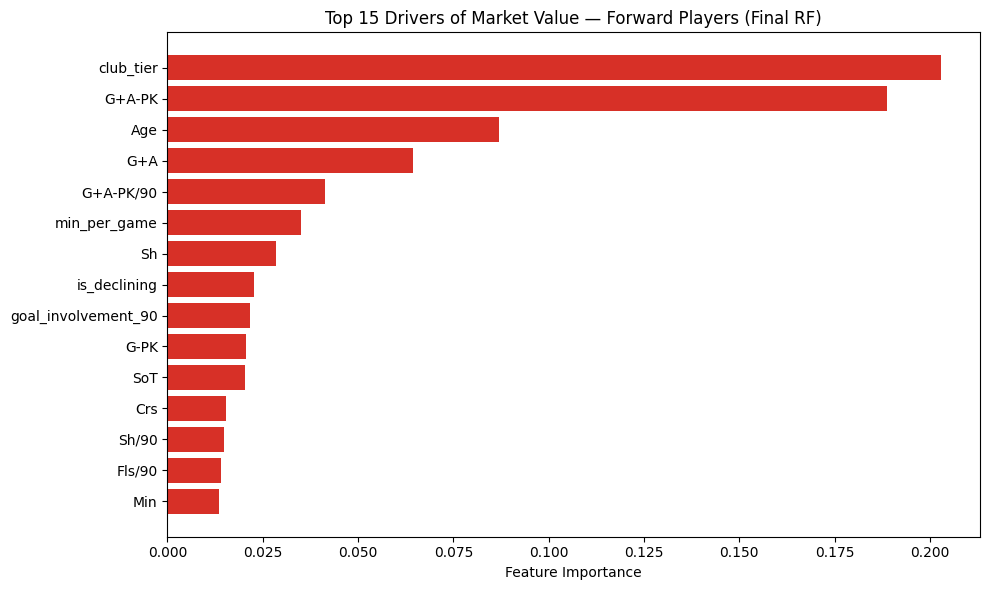


Worst 10 predictions on TEST SET:
      player_name season       actual   predicted       error
       Phil Foden  24-25 €100,000,000 €30,875,285 €69,124,715
             Gavi  23-24  €90,000,000 €20,961,637 €69,038,363
            Pedri  23-24  €80,000,000 €26,482,697 €53,517,303
   Anthony Gordon  24-25  €65,000,000 €12,418,839 €52,581,161
   Alexander Isak  23-24  €75,000,000 €27,795,244 €47,204,756
  Mikel Oyarzabal  22-23  €50,000,000  €5,651,850 €44,348,150
     Lamine Yamal  23-24  €75,000,000 €39,805,080 €35,194,920
        Joelinton  23-24  €40,000,000  €5,042,770 €34,957,230
Christian Pulisic  23-24  €32,000,000 €66,283,123 €34,283,123
   Mohammed Kudus  24-25  €45,000,000 €11,110,049 €33,889,951

Sample predictions from TEST SET:
    player_name season      actual   predicted
   Amine Gouiri  23-24 €28,000,000 €10,799,086
  Tammy Abraham  24-25 €15,000,000 €24,599,038
 Evann Guessand  23-24  €8,000,000  €7,501,576
          Sávio  23-24    €100,000 €23,501,613
   Linton Mai

In [40]:
#FORWARD Random Forests
df_fw = df_outfield[
    df_outfield["Pos"].str.contains("FW", na=False)
].copy()

print(f"Forwards dataset rows: {len(df_fw)}")


df_fw = engineer_features(df_fw, is_gk=False)


FW_FEATURES = [
    # Context
    "club_tier",

    # Age
    "Age", "is_peak_age", "is_young", "is_declining",

    # Playing time
    "MP", "Starts", "Min", "SubIn", "min_per_game",

    # Goal output
    "Gls", "Ast", "G+A", "G-PK", "PK", "PKatt",
    "G+A-PK", "G+A-PK/90", "G-PK/90",

    # Rates
    "G/90", "Ast/90", "goal_involvement_90",

    # Shooting
    "Sh", "SoT", "SoT%", "Sh/90", "SoT/90",
    "G/Sh", "G/SoT", "shot_efficiency", "goal_contrib_per_sh",

    # Defense
    "Fls", "Fld", "Off", "Crs", "Int", "TklW",
    "2CrdY", "OG", "DirectRCrd",
    "CrdY/90", "CrdR/90", "Fls/90", "defensive_actions",

    # Discipline
    "CrdY", "CrdR",

] + [c for c in pos_dummies.columns]

FW_FEATURES = [
    f for f in FW_FEATURES
    if f in df_fw.columns
]


fw_rf_pipeline, fw_rf_coefs, df_fw = run_final_rf_model(
    df_fw,
    FW_FEATURES,
    "Forward Players"
)

#df_fw.to_csv(
  #  "forward_model_predictions_final.csv",
 #   index=False
#)

#fw_rf_coefs.to_csv(
#    "feature_importance_forward_final.csv",
#    index=False
#)

print("\nForward Random Forest models complete and saved.")

Midfield dataset rows: 2312

── Midfield Players | Final Random Forest ──────────────────────────────
Train rows    : 1849
Test rows     : 463
CV R²         : 0.486 ± 0.040  (train set)
CV MAE        : 0.658 ± 0.027  (log scale)
Test R²       : 0.485  ← honest performance on unseen data
Test MAE      : €7,427,614
Test MSE   : 196,958,578,701,717
Test RMSE  : €14,034,193

Top 15 drivers:
          feature  importance
        club_tier    0.267805
              Age    0.110388
           G+A-PK    0.099250
               Sh    0.052052
     min_per_game    0.041160
              G+A    0.037036
     is_declining    0.027432
              Min    0.026780
              SoT    0.022926
              Crs    0.020657
              Fld    0.019622
           Fls/90    0.019327
defensive_actions    0.017393
          CrdY/90    0.017341
           Starts    0.015173


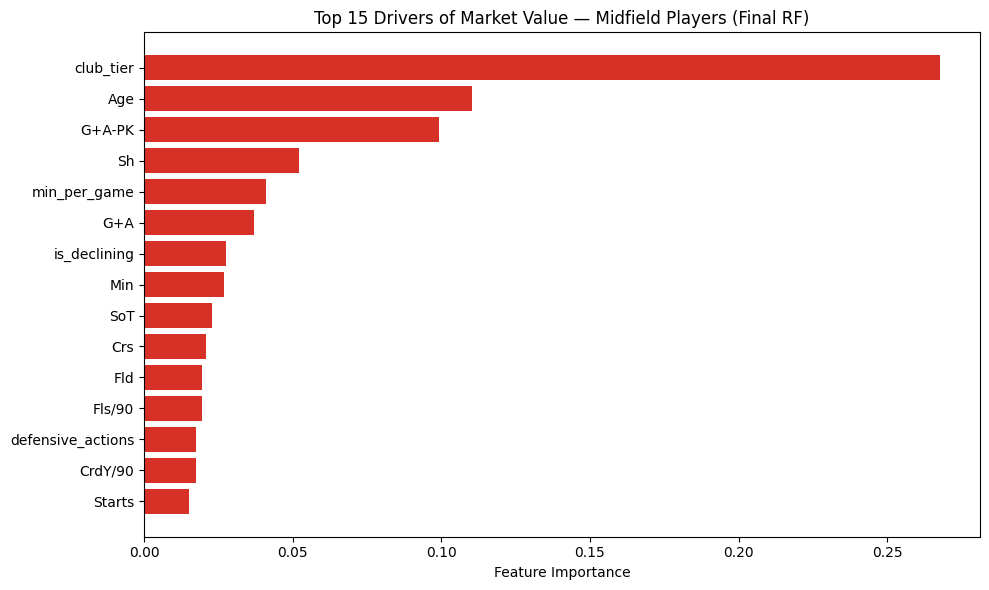


Worst 10 predictions on TEST SET:
        player_name season       actual   predicted        error
    Vinicius Junior  24-25 €200,000,000 €78,322,333 €121,677,667
     Erling Haaland  23-24 €180,000,000 €66,687,103 €113,312,897
    Jude Bellingham  23-24 €180,000,000 €85,769,312  €94,230,688
        Declan Rice  24-25 €120,000,000 €53,943,287  €66,056,713
Alexis Mac Allister  24-25 €100,000,000 €43,503,777  €56,496,223
              Sávio  24-25     €100,000 €48,366,279  €48,266,279
            Rodrygo  24-25 €100,000,000 €53,395,121  €46,604,879
    Mikel Oyarzabal  22-23  €50,000,000  €5,321,529  €44,678,471
       Amadou Onana  24-25  €50,000,000  €9,990,771  €40,009,229
     Nicolò Barella  24-25  €80,000,000 €40,247,900  €39,752,100

Sample predictions from TEST SET:
    player_name season       actual   predicted
 Julian Ryerson  24-25  €20,000,000 €37,143,774
       Angeliño  23-24   €8,000,000  €4,988,878
Antoine Semenyo  23-24  €10,000,000 €10,979,583
Jude Bellingham  23-24 

In [41]:
#Midfield Random Forests
df_mf = df_outfield[
    df_outfield["Pos"].str.contains("MF", na=False)
].copy()

print(f"Midfield dataset rows: {len(df_mf)}")


df_mf = engineer_features(df_mf, is_gk=False)


MF_FEATURES = [
    # Context
    "club_tier",

    # Age
    "Age", "is_peak_age", "is_young", "is_declining",

    # Playing time
    "MP", "Starts", "Min", "SubIn", "min_per_game",

    # Goal output
    "Gls", "Ast", "G+A", "G-PK", "PK", "PKatt",
    "G+A-PK", "G+A-PK/90", "G-PK/90",

    # Rates
    "G/90", "Ast/90", "goal_involvement_90",

    # Shooting
    "Sh", "SoT", "SoT%", "Sh/90", "SoT/90",
    "G/Sh", "G/SoT", "shot_efficiency", "goal_contrib_per_sh",

    # Defense
    "Fls", "Fld", "Off", "Crs", "Int", "TklW",
    "2CrdY", "OG", "DirectRCrd",
    "CrdY/90", "CrdR/90", "Fls/90", "defensive_actions",

    # Discipline
    "CrdY", "CrdR",

] + [c for c in pos_dummies.columns]

MF_FEATURES = [
    f for f in MF_FEATURES
    if f in df_mf.columns
]


mf_rf_pipeline, mf_rf_coefs, df_mf = run_final_rf_model(
    df_mf,
    MF_FEATURES,
    "Midfield Players"
)

#df_mf.to_csv(
 #   "midfield_model_predictions_final.csv",
 #   index=False
#)

#mf_rf_coefs.to_csv(
#    "feature_importance_midfield_final.csv",
#    index=False
#)

print("\nMidfield Random Forest models complete and saved.")

Defender dataset rows: 1605

── Defense Players | Final Random Forest ──────────────────────────────
Train rows    : 1284
Test rows     : 321
CV R²         : 0.479 ± 0.054  (train set)
CV MAE        : 0.690 ± 0.019  (log scale)
Test R²       : 0.477  ← honest performance on unseen data
Test MAE      : €5,312,020
Test MSE   : 89,164,152,887,559
Test RMSE  : €9,442,677

Top 15 drivers:
          feature  importance
        club_tier    0.289752
              Age    0.181684
     min_per_game    0.053826
     is_declining    0.047253
              Min    0.044069
               Sh    0.034247
            Sh/90    0.027389
              Crs    0.026824
           Starts    0.025575
           Fls/90    0.022898
defensive_actions    0.019992
             TklW    0.019436
          CrdY/90    0.018107
              Int    0.015882
              Fld    0.015266


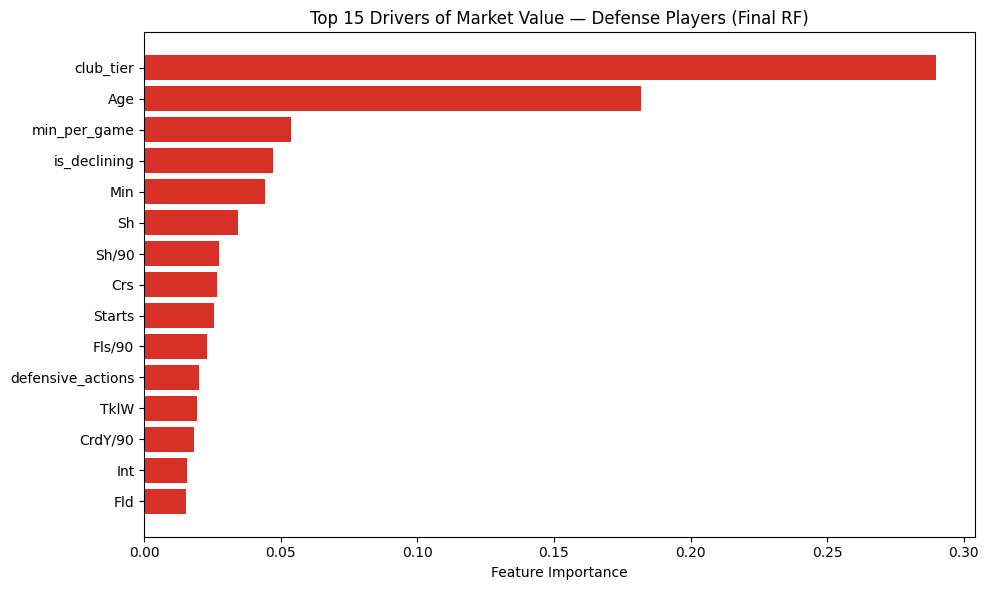


Worst 10 predictions on TEST SET:
       player_name season      actual   predicted       error
      Éder Militão  23-24 €70,000,000 €15,762,449 €54,237,551
      Dean Huijsen  24-25 €60,000,000  €6,629,040 €53,370,960
     Ronald Araujo  22-23 €70,000,000 €30,941,709 €39,058,291
  Giorgio Scalvini  23-24 €45,000,000  €7,857,250 €37,142,750
       Fran García  24-25    €125,000 €34,985,066 €34,860,066
 Eduardo Camavinga  22-23 €60,000,000 €26,132,414 €33,867,586
    Piero Hincapié  23-24 €40,000,000  €7,281,493 €32,718,507
        Marquinhos  22-23 €12,000,000 €40,577,207 €28,577,207
       John Stones  23-24 €38,000,000  €9,913,216 €28,086,784
Warren Zaïre-Emery  23-24 €60,000,000 €33,208,652 €26,791,348

Sample predictions from TEST SET:
        player_name season      actual   predicted
             Juanpe  24-25    €900,000    €880,889
           Henrique  23-24    €150,000  €2,918,494
     Luca Caldirola  24-25    €800,000    €870,753
    Alejandro Balde  24-25 €60,000,000 €35,0

In [42]:
#Defender Random Forests
df_def = df_outfield[
    df_outfield["Pos"].str.contains("DF", na=False)
].copy()

print(f"Defender dataset rows: {len(df_def)}")


df_def = engineer_features(df_def, is_gk=False)


DF_FEATURES = [
    # Context
    "club_tier",

    # Age
    "Age", "is_peak_age", "is_young", "is_declining",

    # Playing time
    "MP", "Starts", "Min", "SubIn", "min_per_game",

    # Goal output
    "Gls", "Ast", "G+A", "G-PK", "PK", "PKatt",
    "G+A-PK", "G+A-PK/90", "G-PK/90",

    # Rates
    "G/90", "Ast/90", "goal_involvement_90",

    # Shooting
    "Sh", "SoT", "SoT%", "Sh/90", "SoT/90",
    "G/Sh", "G/SoT", "shot_efficiency", "goal_contrib_per_sh",

    # Defense
    "Fls", "Fld", "Off", "Crs", "Int", "TklW",
    "2CrdY", "OG", "DirectRCrd",
    "CrdY/90", "CrdR/90", "Fls/90", "defensive_actions",

    # Discipline
    "CrdY", "CrdR",

] + [c for c in pos_dummies.columns]

DF_FEATURES = [
    f for f in DF_FEATURES
    if f in df_def.columns
]

def_rf_pipeline, def_rf_coefs, df_def = run_final_rf_model(
    df_def,
    DF_FEATURES,
    "Defense Players"
)

#df_def.to_csv(
 #   "defense_model_predictions_final.csv",
 #   index=False
#)

#def_rf_coefs.to_csv(
#    "feature_importance_defense_final.csv",
#    index=False
#)

print("\Defense Random Forest models complete and saved.")

Forward Rows: 1063

── Forward Players | Linear Regression ──────────────────────────────
Train rows    : 850
Test rows     : 213
CV R²         : 0.515 ± 0.058  (train set)
CV MAE        : 0.664 ± 0.042  (log scale)
Test R²       : 0.533  ← honest performance on unseen data
Test MAE      : €9,007,634
Test MSE   : 240,536,469,783,416
Test RMSE  : €15,509,238

Top 15 drivers (by absolute coefficient):
            feature  coefficient
          G+A-PK/90     1.704972
            G-PK/90    -1.492616
               G/90     1.054148
goal_involvement_90    -0.877545
          club_tier    -0.462895
             Ast/90    -0.327619
                Age    -0.307712
               G/Sh    -0.192415
       min_per_game     0.191227
               TklW     0.182459
                 Sh     0.130923
                Min     0.118662
        is_peak_age     0.107865
               G-PK     0.107249
                Int    -0.103229


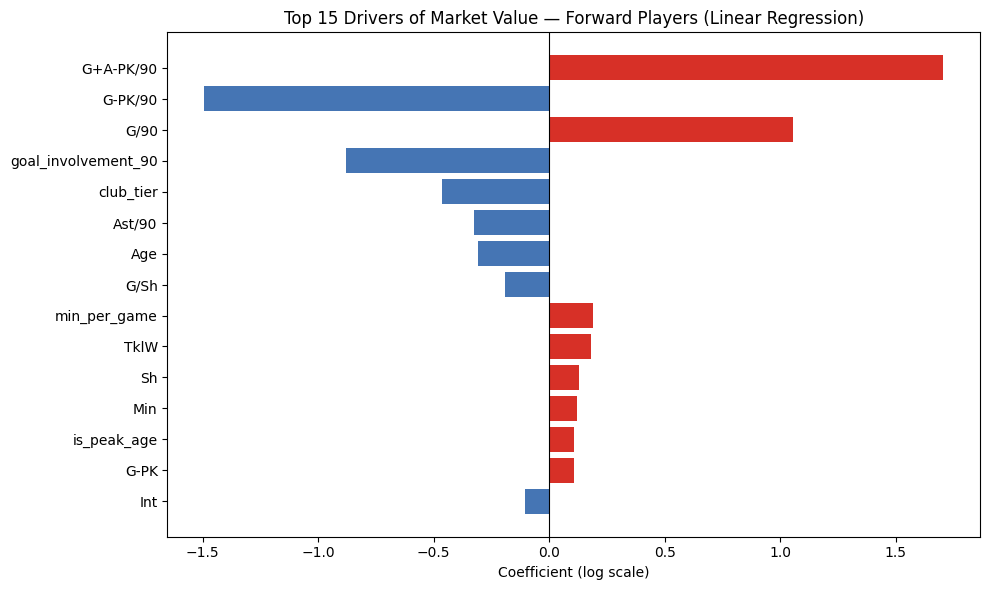


Worst 10 predictions on TEST SET:
       player_name season       actual    predicted       error
    Victor Osimhen  22-23 €100,000,000 €192,340,329 €92,340,329
        Phil Foden  24-25 €100,000,000  €29,972,844 €70,027,156
              Gavi  23-24  €90,000,000  €29,011,569 €60,988,431
             Pedri  23-24  €80,000,000  €22,419,290 €57,580,710
   Mikel Oyarzabal  22-23  €50,000,000   €7,369,993 €42,630,007
    Alexander Isak  23-24  €75,000,000  €32,422,599 €42,577,401
    Anthony Gordon  24-25  €65,000,000  €22,781,878 €42,218,122
 Christian Pulisic  23-24  €32,000,000  €72,021,706 €40,021,706
        Ivan Toney  22-23  €50,000,000  €13,252,341 €36,747,659
Gabriel Martinelli  23-24  €70,000,000  €34,257,024 €35,742,976

Sample predictions from TEST SET:
    player_name season      actual   predicted
   Amine Gouiri  23-24 €28,000,000 €16,430,959
  Tammy Abraham  24-25 €15,000,000 €15,948,817
 Evann Guessand  23-24  €8,000,000  €5,988,470
          Sávio  23-24    €100,000 €16

In [43]:
#Forwards Linear Regression
df_fw = df_outfield[
    df_outfield["Pos"].str.contains("FW", na=False)
].copy()

print("Forward Rows:", len(df_fw))

df_fw = engineer_features(df_fw, is_gk=False)

FW_FEATURES = [
    f for f in OUTFIELD_FEATURES_FINAL
    if f in df_fw.columns
]

fw_lr_pipeline, fw_lr_coefs, df_fw = run_final_lr_model(
    df_fw,
    FW_FEATURES,
    "Forward Players"
)

#df_fw.to_csv(
#    "forward_model_predictions_final.csv",
#    index=False
#)

#fw_lr_coefs.to_csv(
#    "feature_importance_forward_final.csv",
#    index=False
#)

print("\nForward models complete and saved.")

Midfield Rows: 2312

── Midfield Players | Linear Regression ──────────────────────────────
Train rows    : 1849
Test rows     : 463
CV R²         : 0.483 ± 0.052  (train set)
CV MAE        : 0.665 ± 0.027  (log scale)
Test R²       : 0.494  ← honest performance on unseen data
Test MAE      : €7,247,419
Test MSE   : 178,796,028,130,110
Test RMSE  : €13,371,463

Top 15 drivers (by absolute coefficient):
            feature  coefficient
          club_tier    -0.510920
          G+A-PK/90     0.410568
                Min    -0.391894
       min_per_game     0.356354
                Age    -0.355105
goal_involvement_90    -0.185027
             Fls/90    -0.182905
                SoT     0.178473
               TklW     0.131161
                 Sh     0.128980
                 MP     0.111104
             pos_MF     0.101786
       is_declining    -0.098023
               G/90     0.089230
           is_young    -0.086109


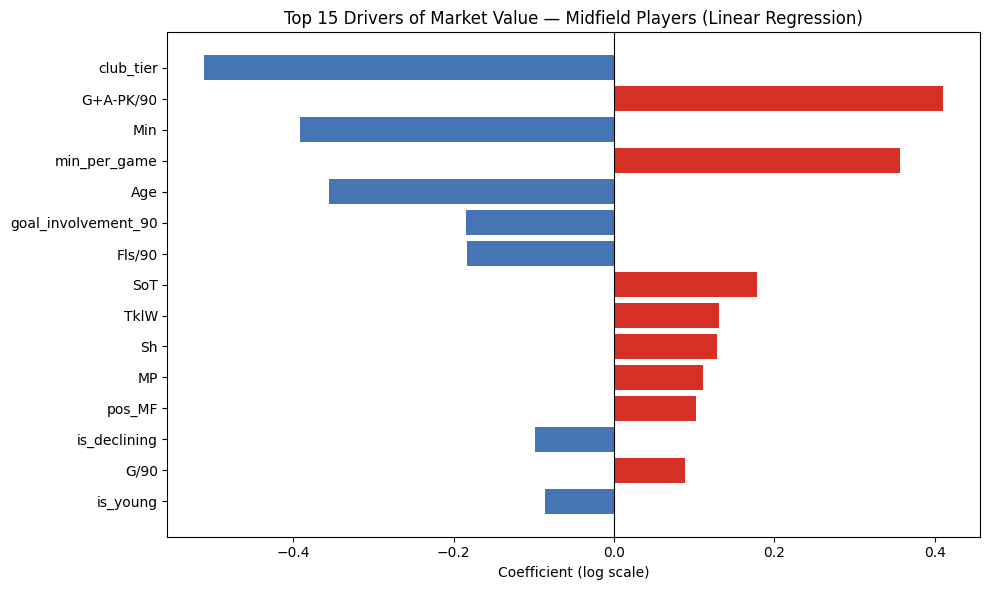


Worst 10 predictions on TEST SET:
        player_name season       actual    predicted        error
    Vinicius Junior  24-25 €200,000,000  €78,106,375 €121,893,625
        Declan Rice  24-25 €120,000,000  €43,545,269  €76,454,731
        Cole Palmer  23-24  €80,000,000 €145,878,852  €65,878,852
    Marcus Rashford  22-23  €80,000,000 €132,794,540  €52,794,540
              Sávio  24-25     €100,000  €48,696,537  €48,596,537
            Rodrygo  24-25 €100,000,000  €51,638,556  €48,361,444
     Nicolò Barella  24-25  €80,000,000  €33,213,788  €46,786,212
Alexis Mac Allister  24-25 €100,000,000  €53,244,590  €46,755,410
     Nicolò Barella  23-24  €75,000,000  €30,204,056  €44,795,944
    Mikel Oyarzabal  22-23  €50,000,000   €5,959,085  €44,040,915

Sample predictions from TEST SET:
    player_name season       actual    predicted
 Julian Ryerson  24-25  €20,000,000  €19,384,347
       Angeliño  23-24   €8,000,000   €6,707,545
Antoine Semenyo  23-24  €10,000,000  €12,265,392
Jude Bel

In [44]:
#Midfield Linear Regression
df_mf = df_outfield[
    df_outfield["Pos"].str.contains("MF", na=False)
].copy()

print("Midfield Rows:", len(df_mf))

df_mf = engineer_features(df_mf, is_gk=False)

MF_FEATURES = [
    f for f in OUTFIELD_FEATURES_FINAL
    if f in df_mf.columns
]

mf_lr_pipeline, mf_lr_coefs, df_mf = run_final_lr_model(
    df_mf,
    MF_FEATURES,
    "Midfield Players"
)

#df_mf.to_csv(
   # "midfield_model_predictions_final.csv",
   # index=False
#)

#mf_lr_coefs.to_csv(
#    "feature_importance_midfield_final.csv",
#    index=False
#)

print("\nMidfield models complete and saved.")

Defense Rows: 1605

── Defense Players | Linear Regression ──────────────────────────────
Train rows    : 1284
Test rows     : 321
CV R²         : 0.457 ± 0.050  (train set)
CV MAE        : 0.694 ± 0.028  (log scale)
Test R²       : 0.467  ← honest performance on unseen data
Test MAE      : €5,342,913
Test MSE   : 87,066,437,589,212
Test RMSE  : €9,330,940

Top 15 drivers (by absolute coefficient):
            feature  coefficient
goal_involvement_90    -1.339868
               G/90     0.974837
             Ast/90     0.598874
          club_tier    -0.573779
                Age    -0.551548
          G+A-PK/90     0.545689
            G-PK/90    -0.401449
                Min     0.296353
           is_young    -0.217641
                Crs    -0.146706
            CrdY/90     0.143203
             SoT/90    -0.138815
       is_declining    -0.127676
               CrdY    -0.118332
              Sh/90     0.111226


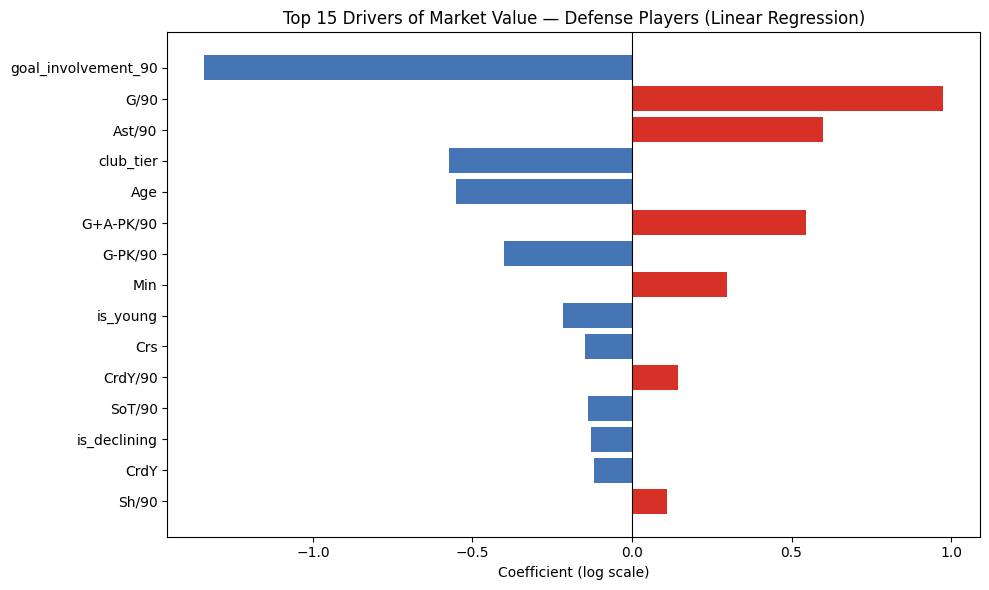


Worst 10 predictions on TEST SET:
      player_name season      actual   predicted       error
     Éder Militão  23-24 €70,000,000  €7,355,532 €62,644,468
     Dean Huijsen  24-25 €60,000,000  €7,286,863 €52,713,137
Eduardo Camavinga  22-23 €60,000,000 €21,032,404 €38,967,596
   Josko Gvardiol  23-24 €75,000,000 €37,795,896 €37,204,104
  Alejandro Balde  24-25 €60,000,000 €26,904,615 €33,095,385
    Ronald Araujo  22-23 €70,000,000 €37,257,667 €32,742,333
   Piero Hincapié  23-24 €40,000,000  €8,252,918 €31,747,082
      John Stones  23-24 €38,000,000  €8,436,325 €29,563,675
          Murillo  23-24 €35,000,000  €6,612,028 €28,387,972
      Fran García  24-25    €125,000 €25,173,582 €25,048,582

Sample predictions from TEST SET:
        player_name season      actual   predicted
             Juanpe  24-25    €900,000    €593,904
           Henrique  23-24    €150,000  €3,814,353
     Luca Caldirola  24-25    €800,000    €617,224
    Alejandro Balde  24-25 €60,000,000 €26,904,615
    

In [45]:
#Defense Linear Regression
df_def = df_outfield[
    df_outfield["Pos"].str.contains("DF", na=False)
].copy()

print("Defense Rows:", len(df_def))

df_def = engineer_features(df_def, is_gk=False)

DEF_FEATURES = [
    f for f in OUTFIELD_FEATURES_FINAL
    if f in df_def.columns
]

def_lr_pipeline, def_lr_coefs, df_def = run_final_lr_model(
    df_def,
    DEF_FEATURES,
    "Defense Players"
)

#df_def.to_csv(
#    "defense_model_predictions_final.csv",
#    index=False
#)

#def_lr_coefs.to_csv(
#    "feature_importance_defense_final.csv",
#    index=False
#)

print("\nDefense models complete and saved.")

In [ ]:
#K-Means Clustering
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


if "df_gk_active" not in dir():
    df_gk_active = df_gk_model[df_gk_model["Min"] >= 900].copy()

def dedupe_columns(df):
    return df.loc[:, ~df.columns.duplicated()]

df_outfield  = dedupe_columns(df_outfield)
df_gk_active = dedupe_columns(df_gk_active)

if "log_value" not in df_outfield.columns:
    df_outfield["log_value"] = np.log1p(df_outfield["value"])

if "log_value" not in df_gk_active.columns:
    df_gk_active["log_value"] = np.log1p(df_gk_active["value"])


# OUTFIELD CLUSTERS
outfield_cluster_features = [
    f for f in OUTFIELD_FEATURES_FINAL
    if f in df_outfield.columns
]

X_out = df_outfield[outfield_cluster_features].fillna(0)

scaler_out = StandardScaler()
X_out_scaled = scaler_out.fit_transform(X_out)

kmeans_out = KMeans(n_clusters=5, random_state=42, n_init=10)
df_outfield["cluster"] = kmeans_out.fit_predict(X_out_scaled)

# GOALKEEPER CLUSTERS
gk_cluster_features = [
    f for f in GK_FEATURES_FINAL
    if f in df_gk_active.columns
]

X_gk = df_gk_active[gk_cluster_features].fillna(0)

scaler_gk = StandardScaler()
X_gk_scaled = scaler_gk.fit_transform(X_gk)

kmeans_gk = KMeans(n_clusters=3, random_state=42, n_init=10)
df_gk_active["cluster"] = kmeans_gk.fit_predict(X_gk_scaled)


def run_final_model_with_clusters(df, features, label):

    X = df[features].fillna(0)
    y = df["log_value"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", RandomForestRegressor(
            n_estimators=700,
            max_depth=12,
            min_samples_leaf=5,
            max_features=0.6,
            n_jobs=-1,
            random_state=42
        ))
    ])

    cv_r2 = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="r2")
    cv_mae = cross_val_score(pipeline, X_train, y_train, cv=5,
                             scoring="neg_mean_absolute_error")

    pipeline.fit(X_train, y_train)

    preds = pipeline.predict(X_test)

    test_r2 = r2_score(y_test, preds)
    test_mae = mean_absolute_error(np.expm1(y_test), np.expm1(preds))
    test_mse = mean_squared_error(np.expm1(y_test), np.expm1(preds))
    test_rmse = np.sqrt(test_mse)

    print(f"\n── {label} ──────────────────────────────")
    print(f"CV R²: {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")
    print(f"Test R²: {test_r2:.3f}")
    print(f"MAE: €{test_mae:,.0f}")
    print(f"RMSE: €{test_rmse:,.0f}")

    return pipeline


OUTFIELD_FEATURES_WITH_CLUSTER = OUTFIELD_FEATURES_FINAL + ["cluster"]
GK_FEATURES_WITH_CLUSTER = GK_FEATURES_FINAL + ["cluster"]


outfield_rf_cluster_pipeline = run_final_model_with_clusters(
    df_outfield,
    OUTFIELD_FEATURES_WITH_CLUSTER,
    "Outfield Players"
)

gk_rf_cluster_pipeline = run_final_model_with_clusters(
    df_gk_active,
    GK_FEATURES_WITH_CLUSTER,
    "Goalkeepers"
)

def plot_clusters(df, features, title, filename, n_clusters):

    X = df[features].fillna(0)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    plt.figure(figsize=(10, 7))

    scatter = plt.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=df["cluster"],
        alpha=0.7
    )

    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    plt.title(title)
    plt.colorbar(scatter)

    plt.tight_layout()
    #plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


plot_clusters(
    df_gk_active,
    gk_cluster_features,
    "Goalkeeper Clusters",
    "goalkeeper_clusters.png",
    3
)

plot_clusters(
    df_outfield,
    outfield_cluster_features,
    "Outfield Player Clusters",
    "outfield_clusters.png",
    5
)

In [47]:
# Choose features used for clustering
features_gk = GK_FEATURES_FINAL  # or OUTFIELD_FEATURES_FINAL

gk_profile = df_gk_active.copy()

cluster_summary_gk = gk_profile.groupby("cluster")[features_gk].mean()

#cluster_summary_gk.to_csv('gk_clusters_summary.csv', index=False)

features_outfield = OUTFIELD_FEATURES_FINAL  # or OUTFIELD_FEATURES_FINAL

outfield_profile = df_outfield.copy()

cluster_summary_outfield = outfield_profile.groupby("cluster")[features_outfield].mean()

#cluster_summary_outfield.to_csv('outfield_clusters_summary.csv', index=False)

print(cluster_summary_gk)
print(cluster_summary_outfield)

         club_tier        Age  is_peak_age  is_young  is_declining         MP  \
cluster                                                                         
0         2.012195  28.682927     0.597561  0.207317      0.146341  17.268293   
1         1.000000  29.500000     1.000000  0.000000      0.000000  66.000000   
2         2.172840  28.191358     0.635802  0.203704      0.098765  32.827160   

            Starts          Min         GA      GA90  ...    cs_rate  \
cluster                                               ...              
0        17.109756  1537.829268  21.231707  1.319657  ...  21.359423   
1        61.500000  5427.500000  26.500000  0.939941  ...  35.906250   
2        32.796296  2940.870370  45.487654  1.405254  ...  24.976599   

         cs_per_90  ga_per_sota       CrdY      CrdR   CrdY/90    Fls/90  \
cluster                                                                    
0         0.213171     0.353233   0.829268  0.060976  0.049260  0.025775   
1    

In [ ]:
# Compares the models

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

def extract_metrics(label, model_type, pipeline, df, features):
    X = df[features].fillna(0)
    y = df["log_value"]

    # Reproduce the exact same split used during training
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # CV on train set
    cv_r2 = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="r2")

    # Test set evaluation
    test_preds = pipeline.predict(X_test)
    test_r2    = r2_score(y_test, test_preds)
    test_mae   = mean_absolute_error(np.expm1(y_test), np.expm1(test_preds))
    test_mse   = mean_squared_error(np.expm1(y_test),  np.expm1(test_preds))
    test_rmse  = np.sqrt(test_mse)

    return {
        "label":      label,
        "model_type": model_type,
        "n_rows":     len(df),
        "cv_r2":      round(cv_r2.mean(), 3),
        "cv_r2_std":  round(cv_r2.std(),  3),
        "test_r2":    round(test_r2,       3),
        "test_mae":   round(test_mae,      0),
        "test_mse":   round(test_mse,      0),
        "test_rmse":  round(test_rmse,     0),
    }

all_metrics = []

# 1) All Outfield
all_metrics.append(extract_metrics(
    "All Outfield", "Random Forest",
    outfield_rf_pipeline, df_outfield, OUTFIELD_FEATURES_FINAL
))
all_metrics.append(extract_metrics(
    "All Outfield", "Linear Regression",
    outfield_lr_pipeline, df_outfield, OUTFIELD_FEATURES_FINAL
))

# 2) All Goalkeepers
all_metrics.append(extract_metrics(
    "All Goalkeepers", "Random Forest",
    gk_rf_pipeline, df_gk_model, GK_FEATURES_FINAL
))
all_metrics.append(extract_metrics(
    "All Goalkeepers", "Linear Regression",
    gk_pipeline, df_gk_model, GK_FEATURES_FINAL
))

# 3) EPL
all_metrics.append(extract_metrics(
    "EPL", "Random Forest",
    epl_rf_outfield_pipeline, df_epl_outfield, EPL_OUTFIELD_FEATURES
))
all_metrics.append(extract_metrics(
    "EPL", "Linear Regression",
    epl_lr_outfield_pipeline, df_epl_outfield, EPL_OUTFIELD_FEATURES
))
all_metrics.append(extract_metrics(
    "EPL GK", "Random Forest",
    epl_rf_gk_pipeline, df_epl_gk, EPL_GK_FEATURES
))
all_metrics.append(extract_metrics(
    "EPL GK", "Linear Regression",
    epl_lr_gk_pipeline, df_epl_gk, EPL_GK_FEATURES
))

# 4) Bundesliga
all_metrics.append(extract_metrics(
    "Bundesliga", "Random Forest",
    bundesliga_rf_outfield_pipeline, df_bundesliga_outfield, BUNDESLIGA_OUTFIELD_FEATURES
))
all_metrics.append(extract_metrics(
    "Bundesliga", "Linear Regression",
    bundesliga_lr_outfield_pipeline, df_bundesliga_outfield, BUNDESLIGA_OUTFIELD_FEATURES
))
all_metrics.append(extract_metrics(
    "Bundesliga GK", "Random Forest",
    bundesliga_rf_gk_pipeline, df_bundesliga_gk, BUNDESLIGA_GK_FEATURES
))
all_metrics.append(extract_metrics(
    "Bundesliga GK", "Linear Regression",
    bundesliga_lr_gk_pipeline, df_bundesliga_gk, BUNDESLIGA_GK_FEATURES
))

# 5) La Liga
all_metrics.append(extract_metrics(
    "La Liga", "Random Forest",
    la_liga_rf_outfield_pipeline, df_la_liga_outfield, LA_LIGA_OUTFIELD_FEATURES
))
all_metrics.append(extract_metrics(
    "La Liga", "Linear Regression",
    la_liga_lr_outfield_pipeline, df_la_liga_outfield, LA_LIGA_OUTFIELD_FEATURES
))
all_metrics.append(extract_metrics(
    "La Liga GK", "Random Forest",
    la_liga_rf_gk_pipeline, df_la_liga_gk, LA_LIGA_GK_FEATURES
))
all_metrics.append(extract_metrics(
    "La Liga GK", "Linear Regression",
    la_liga_lr_gk_pipeline, df_la_liga_gk, LA_LIGA_GK_FEATURES
))

# 6) Serie A
all_metrics.append(extract_metrics(
    "Serie A", "Random Forest",
    serie_a_rf_outfield_pipeline, df_serie_a_outfield, SERIE_A_OUTFIELD_FEATURES
))
all_metrics.append(extract_metrics(
    "Serie A", "Linear Regression",
    serie_a_lr_outfield_pipeline, df_serie_a_outfield, SERIE_A_OUTFIELD_FEATURES
))
all_metrics.append(extract_metrics(
    "Serie A GK", "Random Forest",
    serie_a_rf_gk_pipeline, df_serie_a_gk, SERIE_A_GK_FEATURES
))
all_metrics.append(extract_metrics(
    "Serie A GK", "Linear Regression",
    serie_a_lr_gk_pipeline, df_serie_a_gk, SERIE_A_GK_FEATURES
))

# 7) Ligue 1
all_metrics.append(extract_metrics(
    "Ligue 1", "Random Forest",
    ligue1_rf_outfield_pipeline, df_ligue1_outfield, LIGUE1_OUTFIELD_FEATURES
))
all_metrics.append(extract_metrics(
    "Ligue 1", "Linear Regression",
    ligue1_lr_outfield_pipeline, df_ligue1_outfield, LIGUE1_OUTFIELD_FEATURES
))
all_metrics.append(extract_metrics(
    "Ligue 1 GK", "Random Forest",
    ligue1_rf_gk_pipeline, df_ligue1_gk, LIGUE1_GK_FEATURES
))
all_metrics.append(extract_metrics(
    "Ligue 1 GK", "Linear Regression",
    ligue1_lr_gk_pipeline, df_ligue1_gk, LIGUE1_GK_FEATURES
))

# 8) Forwards
all_metrics.append(extract_metrics(
    "Forwards", "Random Forest",
    fw_rf_pipeline, df_fw, FW_FEATURES
))
all_metrics.append(extract_metrics(
    "Forwards", "Linear Regression",
    fw_lr_pipeline, df_fw, FW_FEATURES
))

# 9) Midfielders
all_metrics.append(extract_metrics(
    "Midfielders", "Random Forest",
    mf_rf_pipeline, df_mf, MF_FEATURES
))
all_metrics.append(extract_metrics(
    "Midfielders", "Linear Regression",
    mf_lr_pipeline, df_mf, MF_FEATURES
))

# 10) Defenders
all_metrics.append(extract_metrics(
    "Defenders", "Random Forest",
    def_rf_pipeline, df_def, DF_FEATURES
))
all_metrics.append(extract_metrics(
    "Defenders", "Linear Regression",
    def_lr_pipeline, df_def, DEF_FEATURES
))

# 11) Outfield + Clusters
all_metrics.append(extract_metrics(
    "All Outfield + Clusters", "Random Forest",
    outfield_rf_cluster_pipeline, df_outfield, OUTFIELD_FEATURES_WITH_CLUSTER
))

# 12) GK + Clusters
all_metrics.append(extract_metrics(
    "All Goalkeepers + Clusters", "Random Forest",
    gk_rf_cluster_pipeline, df_gk_active, GK_FEATURES_WITH_CLUSTER
))

# ── Build and print table ─────────────────────────────────────────────────────
metrics_df = pd.DataFrame(all_metrics)

print("=" * 110)
print("FULL MODEL COMPARISON TABLE")
print("=" * 110)
print(
    metrics_df
    .assign(
        CV_R2    = lambda d: d.apply(
            lambda r: f"{r['cv_r2']:.3f} ± {r['cv_r2_std']:.3f}", axis=1
        ),
        Test_R2  = lambda d: d["test_r2"].map("{:.3f}".format),
        Test_MAE = lambda d: d["test_mae"].map("€{:,.0f}".format),
        Test_MSE = lambda d: d["test_mse"].map("€{:,.0f}".format),
        Test_RMSE= lambda d: d["test_rmse"].map("€{:,.0f}".format),
        Gap      = lambda d: (d["cv_r2"] - d["test_r2"]).map("{:+.3f}".format),
        N        = lambda d: d["n_rows"].map("{:,}".format),
    )
    [["label", "model_type", "N", "CV_R2", "Test_R2", "Test_MAE",
      "Test_RMSE", "Test_MSE", "Gap"]]
    .rename(columns={
        "label":      "Dataset",
        "model_type": "Model",
        "N":          "Rows",
        "CV_R2":      "CV R²",
        "Test_R2":    "Test R²",
        "Test_MAE":   "Test MAE",
        "Test_RMSE":  "Test RMSE",
        "Test_MSE":   "Test MSE",
        "Gap":        "CV-Test Gap",
    })
    .sort_values(["Dataset", "Model"])
    .to_string(index=False)
)

rf_df = (
    metrics_df[metrics_df["model_type"] == "Random Forest"]
    .sort_values("test_r2")
    .reset_index(drop=True)
)
lr_df = (
    metrics_df[metrics_df["model_type"] == "Linear Regression"]
    .set_index("label")
    .reindex(rf_df["label"])
    .reset_index()
)

y_pos  = np.arange(len(rf_df))
height = 0.35

fig, axes = plt.subplots(1, 3, figsize=(20, 10))

axes[0].barh(
    y_pos + height / 2, rf_df["test_r2"],
    height=height, color="#08519c", label="Random Forest", alpha=0.85
)
axes[0].barh(
    y_pos - height / 2, lr_df["test_r2"].fillna(0),
    height=height, color="#d73027", label="Linear Regression", alpha=0.85
)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(rf_df["label"], fontsize=8)
axes[0].axvline(0.6, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
axes[0].set_xlabel("Test R²")
axes[0].set_title("Test R²\n(dashed = 0.60 benchmark)")
axes[0].legend(fontsize=8)
axes[0].grid(axis="x", alpha=0.3)

axes[1].barh(
    y_pos + height / 2, rf_df["test_rmse"] / 1e6,
    height=height, color="#08519c", label="Random Forest", alpha=0.85
)
axes[1].barh(
    y_pos - height / 2, lr_df["test_rmse"].fillna(0) / 1e6,
    height=height, color="#d73027", label="Linear Regression", alpha=0.85
)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(rf_df["label"], fontsize=8)
axes[1].set_xlabel("Test RMSE (€M)")
axes[1].set_title("Test RMSE\n(lower is better)")
axes[1].legend(fontsize=8)
axes[1].grid(axis="x", alpha=0.3)

axes[2].barh(
    y_pos + height / 2, rf_df["test_mae"] / 1e6,
    height=height, color="#08519c", label="Random Forest", alpha=0.85
)
axes[2].barh(
    y_pos - height / 2, lr_df["test_mae"].fillna(0) / 1e6,
    height=height, color="#d73027", label="Linear Regression", alpha=0.85
)
axes[2].set_yticks(y_pos)
axes[2].set_yticklabels(rf_df["label"], fontsize=8)
axes[2].set_xlabel("Test MAE (€M)")
axes[2].set_title("Test MAE\n(lower is better)")
axes[2].legend(fontsize=8)
axes[2].grid(axis="x", alpha=0.3)

plt.suptitle(
    "Full Model Comparison — Test R², RMSE, and MAE\nRandom Forest vs Linear Regression",
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig("full_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

#metrics_df.to_csv("full_model_comparison.csv", index=False)
print("\nSaved to full_model_comparison.csv and full_model_comparison.png")
